<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Project 2: Ames Housing sale price

## Problem Statement:

Create a regression model based on the _**Ames Housing Dataset**_. This model will predict the price of a house at sale. <br><br>
Using this model, my group has decided to develop a website where homeowners who wish to sell their property can use to find out what `SalePrice` to sell their property for. The website will have specific fields for visitors to fill and submit details about their property. Using our proprietary machine learning algorithm, the website will generate an estimate visitors can use as reference to quote their property `SalePrice`. 

## Background
---

Project 2 involves using a well-known _**Ames housing data**_ to create a regression model that predicts the price of houses in Ames, IA. The Ames Housing Dataset is an exceptionally detailed and robust dataset with over 80 columns of different features relating to houses. I am allowed to use any and all features that are present in this dataset. <br><br> This is also a [Kaggle challenge](https://www.kaggle.com/competitions/dsi-us-11-project-2-regression-challenge/overview), so I would need to make at least one (and hopefully, multiple) submissions towards this regression challenge. Kaggle leaderboard standings will be determined by root mean squared error (`RMSE`).

### Data provided
There are 3 datasets included in the [`datasets`](datasets/) folder for this project.
* [`sample_sub_reg.csv`](datasets/sample_sub_reg.csv): An example of a correctly formatted submission for this challenge (with a random number provided as predictions for `SalePrice`). My submission to Kaggle must match this format
* [`test.csv`](datasets/test.csv): Contains the test data for my model. This data is fed into my regression model to make predictions. Target variable (`SalePrice`) is excluded from this data.
* [`train.csv`](datasets/train.csv): Contains all of the training data for my model. 

### Goal
To predict the Sale Price for each house. For each Id in the test set, I must predict the value of the SalePrice variable.

## Data Dictionary
---
[Link](http://jse.amstat.org/v19n3/decock/DataDocumentation.txt)

### Contents:
* [Background](#Background)
* [Data Dictionary](#Data-Dictionary)
* [Data Import, Validation & Cleaning](#Data-Import,-Validation-and-Cleaning)
    * [Identifying Outliers](#Identifying-outliers:)
    * [Yes/No feature engineering](#Functions-for-label-encoding-presence/absence-of-attribute:)
    * [Ordinal labelling](#Functions-for-ordinal-label-encoding-of-attributes:)
    * [Value count, grouping](#Value-count-and-grouping-values-of-categorical-features:)
* [Exploratory Data Analysis](#Exploratory-Data-Analysis)
* [Feature selection](#Feature-selection-based-on-correlation-with-SalePrice)
* [Train-Test-Split](#Train-test-split:)
* [Imputation of `Lot Frontage`](#Imputation-of-train-set:)
* [Processed Data](#Processed-Dataframes:)
* [GridSearchCV](#GridSearch-CV)
* [Algorithm](#LassoCV)
* [Multicollinearity](#Multicollinearity-check:)
* [Kaggle Submission](#Kaggle-Submission-preparation)
* [Business case](#Business-case-for-project-2)

## Data Import, Validation and Cleaning
---

In [1]:
# import modules for data import and cleaning
import numpy as np
import pandas as pd

In [2]:
# load data
train_df = pd.read_csv('datasets/train.csv')

### train_df

In [3]:
# check import successful
train_df.head(3)

,Id,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,SalePrice
0,109,533352170,60,RL,NaN,13517,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,3,2010,WD,130500
1,544,531379050,60,RL,43.0,11492,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,4,2009,WD,220000
2,153,535304180,20,RL,68.0,7922,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,1,2010,WD,109000


In [4]:
# to get an idea of how much data I am dealing with
print(f'train_df shape: {train_df.shape}')

train_df shape: (2051, 81)


In [5]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,2051.0,1.474034e+03,8.439808e+02,1.0,753.5,1486.0,2.198000e+03,2930.0
PID,2051.0,7.135900e+08,1.886918e+08,526301100.0,528458140.0,535453200.0,9.071801e+08,924152030.0
MS SubClass,2051.0,5.700878e+01,4.282422e+01,20.0,20.0,50.0,7.000000e+01,190.0
Lot Frontage,1721.0,6.905520e+01,2.326065e+01,21.0,58.0,68.0,8.000000e+01,313.0
Lot Area,2051.0,1.006521e+04,6.742489e+03,1300.0,7500.0,9430.0,1.151350e+04,159000.0
Overall Qual,2051.0,6.112140e+00,1.426271e+00,1.0,5.0,6.0,7.000000e+00,10.0
Overall Cond,2051.0,5.562165e+00,1.104497e+00,1.0,5.0,5.0,6.000000e+00,9.0
Year Built,2051.0,1.971709e+03,3.017789e+01,1872.0,1953.5,1974.0,2.001000e+03,2010.0
Year Remod/Add,2051.0,1.984190e+03,2.103625e+01,1950.0,1964.5,1993.0,2.004000e+03,2010.0
Mas Vnr Area,2029.0,9.969591e+01,1.749631e+02,0.0,0.0,0.0,1.610000e+02,1600.0


_Min and max values of numerical columns look reasonable_

In [6]:
# checking dtypes and null values
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2051 entries, 0 to 2050
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               2051 non-null   int64  
 1   PID              2051 non-null   int64  
 2   MS SubClass      2051 non-null   int64  
 3   MS Zoning        2051 non-null   object 
 4   Lot Frontage     1721 non-null   float64
 5   Lot Area         2051 non-null   int64  
 6   Street           2051 non-null   object 
 7   Alley            140 non-null    object 
 8   Lot Shape        2051 non-null   object 
 9   Land Contour     2051 non-null   object 
 10  Utilities        2051 non-null   object 
 11  Lot Config       2051 non-null   object 
 12  Land Slope       2051 non-null   object 
 13  Neighborhood     2051 non-null   object 
 14  Condition 1      2051 non-null   object 
 15  Condition 2      2051 non-null   object 
 16  Bldg Type        2051 non-null   object 
 17  House Style   

In [7]:
# limit rows to view for easier viewing
train_df.isnull().sum().sort_values(ascending=False)[:27]

Pool QC           2042
Misc Feature      1986
Alley             1911
Fence             1651
Fireplace Qu      1000
Lot Frontage       330
Garage Finish      114
Garage Qual        114
Garage Yr Blt      114
Garage Cond        114
Garage Type        113
Bsmt Exposure       58
BsmtFin Type 2      56
BsmtFin Type 1      55
Bsmt Cond           55
Bsmt Qual           55
Mas Vnr Area        22
Mas Vnr Type        22
Bsmt Half Bath       2
Bsmt Full Bath       2
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
BsmtFin SF 1         1
Garage Cars          1
Mo Sold              0
dtype: int64

In [8]:
# check for percentage of null values in columns
(train_df.isnull().sum().sort_values(ascending=False) * 100 / len(train_df))[:27]

Pool QC           99.561190
Misc Feature      96.830814
Alley             93.174061
Fence             80.497318
Fireplace Qu      48.756704
Lot Frontage      16.089712
Garage Finish      5.558264
Garage Qual        5.558264
Garage Yr Blt      5.558264
Garage Cond        5.558264
Garage Type        5.509508
Bsmt Exposure      2.827889
BsmtFin Type 2     2.730375
BsmtFin Type 1     2.681619
Bsmt Cond          2.681619
Bsmt Qual          2.681619
Mas Vnr Area       1.072647
Mas Vnr Type       1.072647
Bsmt Half Bath     0.097513
Bsmt Full Bath     0.097513
Garage Area        0.048757
Total Bsmt SF      0.048757
Bsmt Unf SF        0.048757
BsmtFin SF 2       0.048757
BsmtFin SF 1       0.048757
Garage Cars        0.048757
Mo Sold            0.000000
dtype: float64

_Linear regression models cannot accept any missing values, so all missing values must be dealt with before model fitting._<br><br>
_There are 6 features that have a significant percentage of null values (`> 10%`), 5 of them are categorical, and the null values have meaning. Using `pd.get_dummies` resulted in about 230 addiional features. So I will use ordinal encoding for features that seemed to have ordinal label values. E.g. `Pool QC`, `Bsmt Cond`. I will follow the ordinal encoding of `Overall Qual` and `Overall Cond` where `10`=Excellent and `1`=Very poor._<br><br>
_The features with small percentages of null values may be related to each other. E.g. `Garage`-related, `Bsmt`-related, or `Mas Vnr`-related. I suspect that some of these may be MAR(Missing At Random) values, meaning they are dependent on the values of other features. If so, dropping the rows may be a reasonable thing to do and also not affect many rows._<br><br>

## Identifying outliers:
---

__**2 methods:**__
1. [Via scatterplot](#Via-visual-identification-on-scatterplots-conducted-in-EDA-below:)
1. [Via Interquartile range](#Via-IQR:) [(StatisticsbyJim)](https://statisticsbyjim.com/basics/interquartile-range/) / [(Geekforgeeks)](https://www.geeksforgeeks.org/how-to-use-pandas-filter-with-iqr/)

##### Via visual identification on scatterplots conducted in EDA section below:

In [9]:
outlier_list = [960,1335,471,694,1035,1141,1897,1939,1409,1885,770,1692,828,966]

In [10]:
len(outlier_list)

14

Based on visual identification from scatterplot, there are only 14 outliers.

##### Via IQR:

In [11]:
# construct quantile table
train_qtiles = train_df.quantile(q=[0.25,0.75]).T
train_qtiles.head()

,0.25,0.75
Id,753.5,2198.0
PID,528458140.0,907180080.0
MS SubClass,20.0,70.0
Lot Frontage,58.0,80.0
Lot Area,7500.0,11513.5


In [12]:
# construct column for IQR
train_qtiles['IQR'] = train_qtiles[0.75] - train_qtiles[0.25]

In [13]:
# construct columns for lowest and highest values within IQR
train_qtiles['low'] = train_qtiles[0.25] - (1.5*train_qtiles['IQR'])
train_qtiles['high'] = train_qtiles[0.75] + (1.5*train_qtiles['IQR'])

In [14]:
# check quantile table
train_qtiles.head()

,0.25,0.75,IQR,low,high
Id,753.5,2198.0,1444.5,-1413.25,4.364750e+03
PID,528458140.0,907180080.0,378721940.0,-39624770.00,1.475263e+09
MS SubClass,20.0,70.0,50.0,-55.00,1.450000e+02
Lot Frontage,58.0,80.0,22.0,25.00,1.130000e+02
Lot Area,7500.0,11513.5,4013.5,1479.75,1.753375e+04


In [15]:
def outliers(q_df, data):
    lst = []
    for col in data.select_dtypes(include=np.number).columns.tolist():
        if col=='Id' or col=='PID' or col=='MS SubClass' \
        or col=='Overall Cond' or col=='Overall Qual' \
        or col=='SalePrice':
            pass
        else:
            lowest = q_df.loc[col,'low']
            highest = q_df.loc[col,'high']
            low_lst = list(data.index[data[col]<lowest].values)
            high_lst = list(data.index[data[col]>highest].values)
            lst += low_lst + high_lst
            # print(f'Feature: {col}')
            # print(f'Low outliers: {low_lst}')
            # print(f'High outliers: {high_lst}')
            # print()
    return set(lst)

In [16]:
len(outliers(train_qtiles, train_df))

1160

In [17]:
len(train_df.columns.tolist())

81

In [18]:
# number of numerical features
len(train_df.select_dtypes(include='number').T)

39

Using interquartile range to identify outliers in numerical features for this data set is not useful because this data contains more than 80 features, and half (39) are numerical features. The number of outliers identified via IQR is 1160, which is a huge proportion of `train_df`.  So at this stage, I decided not to remove outliers identified by IQR, but by visual identification on scatterplot.

##### Functions for label encoding presence/absence of attribute:

In [19]:
def yes_no_col(df,root,new):
    conditions = [
        (df[root]=='Ex') | (df[root]=='Gd')|
        (df[root]=='TA') | (df[root]=='Fa')|
        (df[root]=='Po'), 
        (df[root]=='NA')
    ]
    values = [1, 0]
    df[new] = np.select(conditions, values)

In [20]:
def yes_no_pool(df,root,new):
    conditions = [
        (df[root]=='Ex') | (df[root]=='Gd')|
        (df[root]=='TA') | (df[root]=='Fa'), 
        (df[root]=='NA')
    ]
    values = [1, 0]
    df[new] = np.select(conditions, values)

_**Calling functions to feature engineer:**_

In [21]:
yes_no_col(train_df,root='Bsmt Cond',new='have_bsmt')
yes_no_col(train_df,root='Fireplace Qu',new='have_fireplace')
yes_no_col(train_df,root='Garage Cond',new='have_garage')
yes_no_pool(train_df,root='Pool QC',new='have_pool')

_**Checking that function performed as desired:**_

In [22]:
train_df.groupby('have_bsmt')['Bsmt Cond'].value_counts(dropna=False)

have_bsmt  Bsmt Cond
0          NaN            55
1          TA           1834
           Gd             89
           Fa             65
           Po              5
           Ex              3
Name: Bsmt Cond, dtype: int64

In [23]:
train_df.groupby('have_fireplace')['Fireplace Qu'].value_counts(dropna=False)

have_fireplace  Fireplace Qu
0               NaN             1000
1               Gd               523
                TA               407
                Fa                59
                Ex                31
                Po                31
Name: Fireplace Qu, dtype: int64

In [24]:
train_df.groupby('have_garage')['Garage Cond'].value_counts(dropna=False)

have_garage  Garage Cond
0            NaN             114
1            TA             1868
             Fa               47
             Gd               12
             Po                8
             Ex                2
Name: Garage Cond, dtype: int64

In [25]:
train_df.groupby('have_pool')['Pool QC'].value_counts(dropna=False)

have_pool  Pool QC
0          NaN        2042
1          Gd            4
           Fa            2
           TA            2
           Ex            1
Name: Pool QC, dtype: int64

##### Functions for ordinal label encoding of attributes:

In [26]:
def int_rank1(df,col):
    return df[col].replace({'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1}, inplace=True)

In [27]:
def int_rank2(df,col):
    return df[col].replace({'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, np.nan:0}, inplace=True)

In [28]:
# check original count
train_df['Exter Qual'].value_counts(dropna=False) 

TA    1247
Gd     697
Ex      81
Fa      26
Name: Exter Qual, dtype: int64

In [29]:
# call function
int_rank1(train_df, col='Exter Qual')
int_rank1(train_df, col='Exter Cond')
int_rank1(train_df, col='Heating QC')
int_rank1(train_df, col='Kitchen Qual')

In [30]:
# check function return
train_df['Exter Qual'].value_counts(dropna=False)

3    1247
4     697
5      81
2      26
Name: Exter Qual, dtype: int64

In [31]:
# check original count
train_df['Bsmt Qual'].value_counts(dropna=False)

TA     887
Gd     864
Ex     184
Fa      60
NaN     55
Po       1
Name: Bsmt Qual, dtype: int64

_**Call function:**_

In [32]:
int_rank2(train_df,col='Bsmt Qual')
int_rank2(train_df,col='Bsmt Cond')
int_rank2(train_df,col='Fireplace Qu')
int_rank2(train_df,col='Garage Qual')
int_rank2(train_df,col='Garage Cond')

In [33]:
# check function return
train_df['Bsmt Qual'].value_counts(dropna=False)

3.0    887
4.0    864
5.0    184
2.0     60
0.0     55
1.0      1
Name: Bsmt Qual, dtype: int64

In [34]:
# original count
train_df['Bsmt Exposure'].value_counts(dropna=False)

No     1339
Av      288
Gd      203
Mn      163
NaN      58
Name: Bsmt Exposure, dtype: int64

In [35]:
# more replacement of ordinal categorical values with numerical values
train_df['Utilities'].replace({'AllPub':4, 'NoSewr':3, 'NoSeWa':2, 'ELO':1}, inplace=True)
train_df['Land Slope'].replace({'Gtl':3, 'Mod':2, 'Sev':1}, inplace=True)
train_df['Bsmt Exposure'].replace({'Gd':4, 'Av':3, 'Mn':2, 'No':1, np.nan:0}, inplace=True)
train_df['Heating QC'].replace({'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1}, inplace=True)
train_df['Central Air'].replace({'Y':1, 'N':0}, inplace=True)
train_df['Functional'].replace({'Typ':8, 'Min1':7, 'Min2':6, 'Mod':5, 'Maj1':4, 'Maj2':3, 'Sev':2, 'Sal':1}, inplace=True)  
train_df['Garage Finish'].replace({'Fin':3, 'RFn':2, 'Unf':1, np.nan:0}, inplace=True)
train_df['Pool QC'].replace({'Ex':4, 'Gd':3, 'TA':2, 'Fa':1, np.nan:0}, inplace=True)

In [36]:
# check change
train_df['Bsmt Exposure'].value_counts(dropna=False)

1.0    1339
3.0     288
4.0     203
2.0     163
0.0      58
Name: Bsmt Exposure, dtype: int64

In [37]:
# check what features left that have values still in string form
train_df.dtypes[train_df.dtypes=='object']

MS Zoning         object
Street            object
Alley             object
Lot Shape         object
Land Contour      object
Lot Config        object
Neighborhood      object
Condition 1       object
Condition 2       object
Bldg Type         object
House Style       object
Roof Style        object
Roof Matl         object
Exterior 1st      object
Exterior 2nd      object
Mas Vnr Type      object
Foundation        object
BsmtFin Type 1    object
BsmtFin Type 2    object
Heating           object
Electrical        object
Garage Type       object
Paved Drive       object
Fence             object
Misc Feature      object
Sale Type         object
dtype: object

##### Value count and grouping values of categorical features:

In [38]:
def val_cnt(feature):
    return train_df[[feature]].value_counts(dropna=False)

In [39]:
val_cnt(feature='MS Zoning')

MS Zoning
RL           1598
RM            316
FV            101
C (all)        19
RH             14
A (agr)         2
I (all)         1
dtype: int64

In [40]:
# reduce categorical values by grouping
train_df['MS Zoning'].replace({'RM':'R_others', 'RH':'R_others', 
                              'FV': 'others', 'C (all)':'others', 
                               'A (agr)':'others', 'I (all)':'others'
                              }, inplace=True)
# check changes
val_cnt(feature='MS Zoning')

MS Zoning
RL           1598
R_others      330
others        123
dtype: int64

In [41]:
val_cnt(feature='Street')

Street
Pave      2044
Grvl         7
dtype: int64

In [42]:
val_cnt(feature='Alley')

Alley
NaN      1911
Grvl       85
Pave       55
dtype: int64

In [43]:
# reduce categorical values by grouping
train_df['Alley'].replace({np.nan:0, 'Grvl':1, 'Pave':1   
                              }, inplace=True)
# check changes
val_cnt(feature='Alley')

Alley
0        1911
1         140
dtype: int64

In [44]:
val_cnt(feature='Lot Shape')

Lot Shape
Reg          1295
IR1           692
IR2            55
IR3             9
dtype: int64

In [45]:
# reduce categorical values by grouping
train_df['Lot Shape'].replace({'IR1': 'Irreg', 'IR2':'Irreg', 'IR3':'Irreg'   
                              }, inplace=True)
# check changes
val_cnt(feature='Lot Shape')

Lot Shape
Reg          1295
Irreg         756
dtype: int64

In [46]:
val_cnt(feature='Land Contour')

Land Contour
Lvl             1843
HLS               85
Bnk               80
Low               43
dtype: int64

In [47]:
# reduce categorical values by grouping
train_df['Land Contour'].replace({'HLS': 'unLvl', 'Bnk':'unLvl', 'Low':'unLvl'   
                              }, inplace=True)
# check changes
val_cnt(feature='Land Contour')

Land Contour
Lvl             1843
unLvl            208
dtype: int64

In [48]:
val_cnt(feature='Lot Config')

Lot Config
Inside        1503
Corner         348
CulDSac        131
FR2             60
FR3              9
dtype: int64

In [49]:
# reduce categorical values by grouping
train_df['Lot Config'].replace({'CulDSac':'others', 'FR2':'others', 'FR3':'others'   
                              }, inplace=True)
# check changes
val_cnt(feature='Lot Config')

Lot Config
Inside        1503
Corner         348
others         200
dtype: int64

In [50]:
val_cnt(feature='Neighborhood')

Neighborhood
NAmes           310
CollgCr         180
OldTown         163
Edwards         143
Somerst         130
NridgHt         122
Gilbert         116
Sawyer          111
SawyerW          87
NWAmes           87
Mitchel          82
BrkSide          76
Crawfor          71
IDOTRR           69
Timber           48
NoRidge          48
StoneBr          38
SWISU            32
ClearCr          27
MeadowV          24
Blmngtn          22
BrDale           19
NPkVill          17
Veenker          17
Blueste           6
Greens            3
GrnHill           2
Landmrk           1
dtype: int64

In [51]:
# reduce categorical values by group by zip codes
'''
50014: Bluestem;  Clear Creek; College Creek; edwards; north ames, sawyer west, 
       gilbert, timberland, greens, greenhil
50010: Bloomington heights; Briardale; Brookside; Crawford;  DOT, Meadow village, 
       northridge, northpark villa, northridge heights, northwest ames, 
       old town, sawyer , stone brooke, mitchell, somerset, 
50011: iowa state university, veenker, landmark
'''
train_df['Neighborhood'].replace({'Blmngtn':'pc_50010', 'Blueste':'pc_50014', 'BrDale':'pc_50010',
                                  'BrkSide':'pc_50010', 'ClearCr':'pc_50014', 'CollgCr':'pc_50014',
                                  'Crawfor':'pc_50010', 'Edwards':'pc_50014', 'Gilbert':'pc_50014',
                                  'IDOTRR': 'pc_50010', 'MeadowV': 'pc_50010', 'Mitchel':'pc_50010',
                                  'NAmes':'pc_50014', 'NoRidge':'pc_50010', 'NPkVill':'pc_50010',
                                  'NridgHt':'pc_50010', 'NWAmes':'pc_50010', 'OldTown':'pc_50010',
                                  'SWISU':'pc_50011', 'Sawyer':'pc_50010', 'SawyerW':'pc_50014',
                                  'Somerst':'pc_50010', 'StoneBr':'pc_50010', 'Timber':'pc_50014',
                                  'Veenker':'pc_50011', 'Greens':'pc_50014', 'GrnHill':'pc_50014',
                                  'Landmrk':'pc_50011'
                              }, inplace=True)
# check changes
val_cnt(feature='Neighborhood')

Neighborhood
pc_50010        1079
pc_50014         922
pc_50011          50
dtype: int64

In [52]:
val_cnt(feature='Condition 1')

Condition 1
Norm           1767
Feedr           109
Artery           70
RRAn             36
PosN             27
RRAe             21
PosA             12
RRNn              6
RRNe              3
dtype: int64

In [53]:
# reduce categorical values by grouping
train_df['Condition 1'].replace({'Feedr':'street', 'Artery':'street', 'RRAn':'rail',
                                 'PosN':'feature', 'RRAe':'rail', 'PosA':'feature',
                                 'RRNn':'rail', 'RRNe':'rail'
                              }, inplace=True)
# check changes
val_cnt(feature='Condition 1')

Condition 1
Norm           1767
street          179
rail             66
feature          39
dtype: int64

In [54]:
val_cnt(feature='Condition 2')

Condition 2
Norm           2025
Feedr            11
Artery            5
PosA              3
PosN              3
RRNn              2
RRAe              1
RRAn              1
dtype: int64

In [55]:
# reduce categorical values by grouping
train_df['Condition 2'].replace({'Feedr':'other', 'Artery':'other', 'RRAn':'other',
                                 'PosN':'other', 'RRAe':'other', 'PosA':'other',
                                 'RRNn':'other', 
                              }, inplace=True)
# check changes
val_cnt(feature='Condition 2')

Condition 2
Norm           2025
other            26
dtype: int64

In [56]:
val_cnt(feature='Bldg Type')

Bldg Type
1Fam         1700
TwnhsE        161
Duplex         75
Twnhs          69
2fmCon         46
dtype: int64

In [57]:
# reduce categorical values by grouping
train_df['Bldg Type'].replace({'1Fam':'fam', 'TwnhsE':'twnhs', 'Twnhs':'twnhs',
                                 '2fmCon':'fam'
                              }, inplace=True)
# check changes
val_cnt(feature='Bldg Type')

Bldg Type
fam          1746
twnhs         230
Duplex         75
dtype: int64

In [58]:
val_cnt(feature='House Style')

House Style
1Story         1059
2Story          598
1.5Fin          218
SLvl             94
SFoyer           50
2.5Unf           14
1.5Unf           12
2.5Fin            6
dtype: int64

In [59]:
# reduce categorical values by grouping
train_df['House Style'].replace({'1Story':'1story', '2Story':'2story', '1.5Fin':'1story',
                                 'SLvl':'split', 'SFoyer':'split', '2.5Unf':'2story',
                                 '1.5Unf':'1story', '2.5Fin':'2story'
                              }, inplace=True)
# check changes
val_cnt(feature='House Style')

House Style
1story         1289
2story          618
split           144
dtype: int64

In [60]:
val_cnt(feature='Roof Style')

Roof Style
Gable         1619
Hip            397
Flat            13
Gambrel         12
Mansard          7
Shed             3
dtype: int64

In [61]:
# reduce categorical values by grouping
train_df['Roof Style'].replace({'Hip':'other', 'Flat':'other', 'Gambrel':'other',
                                 'Mansard':'other', 'Shed':'other'
                              }, inplace=True)
# check changes
val_cnt(feature='Roof Style')

Roof Style
Gable         1619
other          432
dtype: int64

In [62]:
val_cnt(feature='Roof Matl')

Roof Matl
CompShg      2025
Tar&Grv        15
WdShngl         5
WdShake         4
ClyTile         1
Membran         1
dtype: int64

In [63]:
# reduce categorical values by grouping
train_df['Roof Matl'].replace({'Tar&Grv':'other', 'WdShngl':'other', 'WdShake':'other',
                                 'ClyTile':'other', 'Membran':'other'
                              }, inplace=True)
# check changes
val_cnt(feature='Roof Matl')

Roof Matl
CompShg      2025
other          26
dtype: int64

In [64]:
val_cnt(feature='Exterior 1st')

Exterior 1st
VinylSd         724
MetalSd         331
HdBoard         300
Wd Sdng         276
Plywood         152
CemntBd          90
BrkFace          64
WdShing          45
AsbShng          33
Stucco           27
BrkComm           3
CBlock            2
Stone             2
AsphShn           1
ImStucc           1
dtype: int64

In [65]:
# reduce categorical values by grouping
'''
vinyl, wood, metal, cement, stone, other
'''
train_df['Exterior 1st'].replace({'HdBoard':'wood', 'Wd Sdng':'wood', 'Plywood':'wood',
                                 'CemntBd':'cement', 'BrkFace':'other', 'WdShing':'wood',
                                 'AsbShng':'other', 'Stucco': 'cement', 'BrkComm':'other',
                                  'CBlock':'cement', 'AsphShn':'other', 'ImStucc':'other', 
                                  'Stone':'other'
                              }, inplace=True)
# check changes
val_cnt(feature='Exterior 1st')

Exterior 1st
wood            773
VinylSd         724
MetalSd         331
cement          119
other           104
dtype: int64

In [66]:
val_cnt(feature='Exterior 2nd')

Exterior 2nd
VinylSd         721
MetalSd         324
HdBoard         275
Wd Sdng         262
Plywood         185
CmentBd          90
Wd Shng          63
BrkFace          34
Stucco           30
AsbShng          28
Brk Cmn          17
ImStucc          11
Stone             6
AsphShn           3
CBlock            2
dtype: int64

In [67]:
# reduce categorical values by grouping
'''
vinyl, wood, metal, cement, stone, other
'''
train_df['Exterior 2nd'].replace({'HdBoard':'wood', 'Wd Sdng':'wood', 'Plywood':'wood',
                                 'CmentBd':'cement', 'BrkFace':'other', 'Wd Shng':'wood',
                                 'AsbShng':'other', 'Stucco': 'cement', 'Brk Cmn':'other',
                                  'CBlock':'cement', 'AsphShn':'other', 'ImStucc':'other', 
                                  'Stone':'other'
                              }, inplace=True)
# check changes
val_cnt(feature='Exterior 2nd')

Exterior 2nd
wood            785
VinylSd         721
MetalSd         324
cement          122
other            99
dtype: int64

In [68]:
val_cnt(feature='Mas Vnr Type')

Mas Vnr Type
None            1218
BrkFace          630
Stone            168
NaN               22
BrkCmn            13
dtype: int64

In [69]:
# reduce categorical values by grouping
'''
none, stone, brick
'''
train_df['Mas Vnr Type'].replace({'BrkFace':'brick', 'BrkCmn':'brick', np.nan:'None',                                
                              }, inplace=True)
# check changes
val_cnt(feature='Mas Vnr Type')

Mas Vnr Type
None            1240
brick            643
Stone            168
dtype: int64

In [70]:
val_cnt(feature='Foundation')

Foundation
PConc         926
CBlock        863
BrkTil        221
Slab           34
Stone           5
Wood            2
dtype: int64

In [71]:
# reduce categorical values by grouping
train_df['Foundation'].replace({'BrkTil':'other', 'Slab':'other', 'Stone':'other', 
                                'Wood':'other'
                              }, inplace=True)
# check changes
val_cnt(feature='Foundation')

Foundation
PConc         926
CBlock        863
other         262
dtype: int64

In [72]:
val_cnt(feature='BsmtFin Type 1')

BsmtFin Type 1
GLQ               615
Unf               603
ALQ               293
BLQ               200
Rec               183
LwQ               102
NaN                55
dtype: int64

In [73]:
# reduce categorical values by grouping
train_df['BsmtFin Type 1'].replace({'ALQ':'other', 'BLQ':'other', 'Rec':'other',
                                    'LwQ':'other', np.nan:'other'
                              }, inplace=True)
# check changes
val_cnt(feature='BsmtFin Type 1')

BsmtFin Type 1
other             833
GLQ               615
Unf               603
dtype: int64

In [74]:
val_cnt(feature='BsmtFin Type 2')

BsmtFin Type 2
Unf               1749
Rec                 80
LwQ                 60
NaN                 56
BLQ                 48
ALQ                 35
GLQ                 23
dtype: int64

In [75]:
# reduce categorical values by grouping
train_df['BsmtFin Type 2'].replace({'Rec':'other', 'LwQ':'other', np.nan:'other',
                                    'BLQ':'other', 'ALQ':'other', 'GLQ':'other'
                              }, inplace=True)
# check changes
val_cnt(feature='BsmtFin Type 2')

BsmtFin Type 2
Unf               1749
other              302
dtype: int64

In [76]:
val_cnt(feature='Heating')

Heating
GasA       2018
GasW         20
Wall          6
Grav          5
OthW          2
dtype: int64

In [77]:
# reduce categorical values by grouping
train_df['Heating'].replace({'GasW':'other', 'Wall':'other', 'Grav':'other',
                             'OthW':'other'
                              }, inplace=True)
# check changes
val_cnt(feature='Heating')

Heating
GasA       2018
other        33
dtype: int64

In [78]:
val_cnt(feature='Electrical')

Electrical
SBrkr         1868
FuseA          140
FuseF           35
FuseP            7
Mix              1
dtype: int64

In [79]:
# reduce categorical values by grouping
train_df['Electrical'].replace({'FuseA':'other', 'FuseF':'other', 'FuseP':'other',
                                'Mix':'other'
                              }, inplace=True)
# check changes
val_cnt(feature='Electrical')

Electrical
SBrkr         1868
other          183
dtype: int64

In [80]:
val_cnt(feature='Garage Type')

Garage Type
Attchd         1213
Detchd          536
BuiltIn         132
NaN             113
Basment          27
2Types           19
CarPort          11
dtype: int64

In [81]:
# reduce categorical values by grouping
'''
others, attached, detached,
'''
train_df['Garage Type'].replace({'BuiltIn':'Attchd', 'Basment':'Attchd', np.nan:'other',
                                 '2Types':'other','CarPort':'Detchd'
                              }, inplace=True)
# check changes
val_cnt(feature='Garage Type')

Garage Type
Attchd         1372
Detchd          547
other           132
dtype: int64

In [82]:
val_cnt(feature='Paved Drive')

Paved Drive
Y              1861
N               151
P                39
dtype: int64

In [83]:
# reduce categorical values by grouping
train_df['Paved Drive'].replace({'N':'other', 'P':'other'
                              }, inplace=True)
# check changes
val_cnt(feature='Paved Drive')

Paved Drive
Y              1861
other           190
dtype: int64

In [84]:
val_cnt(feature='Fence')

Fence
NaN      1651
MnPrv     227
GdPrv      83
GdWo       80
MnWw       10
dtype: int64

In [85]:
# reduce categorical values by grouping
train_df['Fence'].replace({np.nan:0, 'MnPrv':1, 'GdPrv':1, 
                           'GdWo':1, 'MnWw':1
                              }, inplace=True)
# check changes
val_cnt(feature='Fence')

Fence
0        1651
1         400
dtype: int64

In [86]:
val_cnt(feature='Misc Feature')

Misc Feature
NaN             1986
Shed              56
Gar2               4
Othr               3
Elev               1
TenC               1
dtype: int64

In [87]:
# reduce categorical values by grouping
train_df['Misc Feature'].replace({np.nan:0, 'Shed':1, 'Gar2':1, 
                           'Othr':1, 'Elev':1, 'TenC':1
                              }, inplace=True)
# check changes
val_cnt(feature='Misc Feature')

Misc Feature
0               1986
1                 65
dtype: int64

In [88]:
val_cnt(feature='Sale Type')

Sale Type
WD           1781
New           160
COD            63
ConLD          17
CWD            10
ConLI           7
ConLw           5
Con             4
Oth             4
dtype: int64

In [89]:
# reduce categorical values by grouping
'''
warranty deed, contract, others
'''
train_df['Sale Type'].replace({'New':'Oth', 'COD':'Oth', 'ConLD':'Con', 
                           'CWD':'WD', 'ConLI':'Con', 'ConLw':'Con',
                               'WD ':'WD'
                              }, inplace=True)
# check changes
val_cnt(feature='Sale Type')

Sale Type
WD           1791
Oth           227
Con            33
dtype: int64

In [90]:
# check what features left that have values still in string form
train_df.dtypes[train_df.dtypes=='object']

MS Zoning         object
Street            object
Lot Shape         object
Land Contour      object
Lot Config        object
Neighborhood      object
Condition 1       object
Condition 2       object
Bldg Type         object
House Style       object
Roof Style        object
Roof Matl         object
Exterior 1st      object
Exterior 2nd      object
Mas Vnr Type      object
Foundation        object
BsmtFin Type 1    object
BsmtFin Type 2    object
Heating           object
Electrical        object
Garage Type       object
Paved Drive       object
Sale Type         object
dtype: object

### train_dum

In [91]:
prefix_dict = {'Garage Type': 'grge_t','BsmtFin Type 2': 'bsmtf_t2', 
               'BsmtFin Type 1': 'bsmtf_t1','Mas Vnr Type': 'mvt','MS Zoning': 'msz', 
               'Street': 'st', 'Lot Shape':'lt_s','Land Contour': 'ld_c',
               'Lot Config': 'lt_c', 'Neighborhood': 'nbrhd','Condition 1': 'cdn_1', 
               'Condition 2': 'cdn_2', 'Bldg Type': 'bdg_t','House Style': 'hse_s', 
               'Roof Style': 'rf_s', 'Roof Matl': 'rf_m','Exterior 1st': 'ex_1', 
               'Exterior 2nd': 'ex_2', 'Foundation': 'fdn','Heating': 'htg', 
               'Electrical': 'elec', 'Paved Drive': 'pvdr','Sale Type': 'sle_t'
              }

columns_list = ['Garage Type','BsmtFin Type 2','BsmtFin Type 1','Mas Vnr Type','MS Zoning',
                'Street','Lot Shape','Land Contour','Lot Config','Neighborhood',
                'Condition 1','Condition 2','Bldg Type', 'House Style','Roof Style',
                'Roof Matl','Exterior 1st','Exterior 2nd','Foundation','Heating',
                'Electrical','Paved Drive','Sale Type'
               ]

train_dum = pd.get_dummies(data=train_df, prefix=prefix_dict, dummy_na=True, columns=columns_list)
train_dum.head(3)

,Id,PID,MS SubClass,Lot Frontage,Lot Area,Alley,Utilities,Land Slope,Overall Qual,Overall Cond,...,elec_SBrkr,elec_other,elec_nan,pvdr_Y,pvdr_other,pvdr_nan,sle_t_Con,sle_t_Oth,sle_t_WD,sle_t_nan
0,109,533352170,60,NaN,13517,0,4,3,6,8,...,1,0,0,1,0,0,0,0,1,0
1,544,531379050,60,43.0,11492,0,4,3,7,5,...,1,0,0,1,0,0,0,0,1,0
2,153,535304180,20,68.0,7922,0,4,3,5,7,...,1,0,0,1,0,0,0,0,1,0


In [92]:
# no features left that have values still in string form
train_dum.dtypes[train_dum.dtypes=='object']

Series([], dtype: object)

In [93]:
# relook at what null values that are left undummified
train_dum.isnull().sum().sort_values(ascending=False)[:12]

Lot Frontage      330
Garage Yr Blt     114
Mas Vnr Area       22
Bsmt Full Bath      2
Bsmt Half Bath      2
Garage Area         1
Garage Cars         1
Total Bsmt SF       1
Bsmt Unf SF         1
BsmtFin SF 2        1
BsmtFin SF 1        1
cdn_2_other         0
dtype: int64

In [94]:
# percentage of null values in each column of dummified train data
(train_dum.isnull().sum().sort_values(ascending=False) * 100 / len(train_dum))[:12]

Lot Frontage      16.089712
Garage Yr Blt      5.558264
Mas Vnr Area       1.072647
Bsmt Full Bath     0.097513
Bsmt Half Bath     0.097513
Garage Area        0.048757
Garage Cars        0.048757
Total Bsmt SF      0.048757
Bsmt Unf SF        0.048757
BsmtFin SF 2       0.048757
BsmtFin SF 1       0.048757
cdn_2_other        0.000000
dtype: float64

Now there are 2 features left with high percentage of null values (>5%).<br><br> 
For `Lot Frontage` feature, with percentage of null values at 16%, either I would remove the feature, or replace missing values by imputation using `KNN imputation`. However the imputation would only be done after train-test-split on the training set.<br><br>
For `Garage Yr Blt`, the missing values are Missing At Random values, since they seem to be dependent on the values of other `Garage`-related features. They also seem to correspond with properties that have **no garage**. Imputation will likely contribute false information, when these missing values have a reason to be missing. If I drop the rows with missing values in `Garage Yr Blt` feature, I would also lose the data of **no garage** from categorical features `Garage Finish`, `Garage Qual` and `Garage Cond`. So I decided the best course of action is to drop the `Garage Yr Blt` feature and retain the datapoints.<br><br>
As for the other features with percentage of null values at `<5%`, I would keep the feature but drop the rows with the missing values.

In [95]:
'''
Displaying that there is no clear relationship between
`Lot Frontage` feature and other `Lot`-related features
'''
train_df.loc[train_df['Lot Frontage'].isnull(), ['Lot Frontage','Lot Area','Lot Shape','Lot Config']].head(3)

,Lot Frontage,Lot Area,Lot Shape,Lot Config
0,NaN,13517,Irreg,others
7,NaN,12160,Irreg,Inside
8,NaN,15783,Reg,Inside


_There is no discernable pattern or explanation as to why the values are missing for `Lot Frontage` feature. I wish to preserve this feature since this feature also has a high correlation with `SalePrice` (This will be revealed in [corr_03](#Feature-selection-based-on-correlation-with-SalePrice)). I would impute the missing values using `KNN imputation`after train-test-split._ 

In [96]:
'''
Displaying `Garage Yr Blt` missing value relationship 
with other categorical `Garage`-related features
'''
train_df.loc[train_df['Garage Yr Blt'].isnull(), ['Garage Yr Blt','Garage Finish','Garage Cars','Garage Area','Garage Qual','Garage Cond']].head(3)

,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond
28,NaN,0.0,0.0,0.0,0.0,0.0
53,NaN,0.0,0.0,0.0,0.0,0.0
65,NaN,0.0,0.0,0.0,0.0,0.0


_Rows with missing values in the features with **<5%** null values_

In [97]:
train_df.loc[train_df['Garage Cars'].isnull(), ['Garage Yr Blt','Garage Finish','Garage Cars','Garage Area','Garage Qual','Garage Cond']]

,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond
1712,NaN,0.0,NaN,NaN,0.0,0.0


In [98]:
train_df.loc[train_df['BsmtFin SF 2'].isnull(), ['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin SF 1','BsmtFin Type 2','BsmtFin SF 2','Bsmt Unf SF','Total Bsmt SF']]

,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF
1327,0.0,0.0,0.0,other,NaN,other,NaN,NaN,NaN


In [99]:
train_df.loc[train_df['Bsmt Full Bath'].isnull(), ['Bsmt Full Bath','Bsmt Half Bath']]

,Bsmt Full Bath,Bsmt Half Bath
616,NaN,NaN
1327,NaN,NaN


In [100]:
'''
these have blank spaces in the source data, 
the np.nan values have been grouped with `None` values done above
So likely these are MCAR values. 
'''
train_df.loc[train_df['Mas Vnr Area'].isnull(), ['Mas Vnr Area','Mas Vnr Type']].head(3)

,Mas Vnr Area,Mas Vnr Type
22,NaN,None
41,NaN,None
86,NaN,None


To get the list of row indices to drop, I get the list of row indices with null values in the `Garage Cars`, `Bsmt Full Bath` and `Mas Vnr Area` features.

In [101]:
list1 = train_df.index[train_df['Garage Cars'].isnull()].tolist()
list1

[1712]

Since the row with `BsmtFin SF 2` null value is also has null value in `Bsmt Full Bath`, I will just get the row indices from `Bsmt Full Bath` null list 

In [102]:
list2 = train_df.index[train_df['Bsmt Full Bath'].isnull()].tolist()
list2

[616, 1327]

In [103]:
list3 = train_df.index[train_df['Mas Vnr Area'].isnull()].tolist()
list3[:5]

[22, 41, 86, 212, 276]

_Join the 3 lists together, may contain duplicate indices, so will convert to set, which only keep unique values_

In [104]:
drop_list = list1 + list2 + list3
len(drop_list)

25

In [105]:
drop_set = set(drop_list)
len(drop_set) # no duplicate indices

25

### train_drop

In [106]:
'''
created new dataframe variable just in case I needed 
the dataframe without any dropped rows and/or feature(s) to go back to
'''
train_drop = train_dum.drop(index=drop_set, columns=['Garage Yr Blt'])

In [107]:
# checking what null values that are left
train_drop.isnull().sum().sort_values(ascending=False)[:3]

Lot Frontage    324
Id                0
cdn_2_Norm        0
dtype: int64

In [108]:
# percentage of null values that are left
(train_drop.isnull().sum().sort_values(ascending=False) * 100 / len(train_drop))[:3]

Lot Frontage    15.992103
Id               0.000000
cdn_2_Norm       0.000000
dtype: float64

## Exploratory Data Analysis
---

_Before train-test-split, outliers need to be dealt with, especially for linear regression models. Linear regression models are easily influenced by outliers._

__Contents:__
1. [Distribution exploration](#Exploring-distributions-using-histograms-and-scatterplots:)
1. [Outliers identified from scatterplots](#Outliers-identified-via-scatterplots-in-EDA:)
1. [Data excluding outliers](#train_df1)

_For exploration of trends within the train data vs. `SalePrice` feature, I would use `train_df` (no rows and columns dropped, and no dummification), for easier comparison of the features._

## Exploring distributions using histograms and scatterplots:
---

In [109]:
# import modules for data exploration
from scipy import stats
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

Scatterplot is useful to reveal outliers. Histogram is useful to show distribution of values, but not outliers, as outliers usually appear in low frequency, so the x-axis would be unusually long with no peak. And it would be difficult to define what is the threshold for outliers from a histogram.<br><br>
Since I am ultimately trying to predict `SalePrice`, I will be comparing numerical features with `SalePrice` to determine outliers.

**Numerical features for exploration are:** <br>
[`Lot Frontage`](#Lot-Frontage-distribution:); [`Lot Area`](#Lot-Area-distribution:); [`Year Built`](#Year-Built-distribution:); [`Year Remod/Add`](#Year-Remod/Add-distribution:); [`Mas Vnr Area`](#Mas-Vnr-Area-distribution:); [`BsmtFin SF 1`](#BsmtFin-SF-1-distribution:); [`BsmtFin SF 2`](#BsmtFin-SF-2-distribution:); [`Bsmt Unf SF`](#Bsmt-Unf-SF-distribution:); [`Total Bsmt SF`](#Total-Bsmt-SF-distribution:); [`1st Flr SF`](#1st-Flr-SF-distribution:); [`2nd Flr SF`](#2nd-Flr-SF-distribution:); [`Low Qual Fin SF`](#Low-Qual-Fin-SF-distribution:); [`Gr Liv Area`](#Gr-Liv-Area-distribution:); [`Bsmt Full Bath`](#Bsmt-Full-Bath-distribution:); [`Bsmt Half Bath`](#Bsmt-Half-Bath-distribution:); [`Full Bath`](#Full-Bath-distribution:); [`Half Bath`](#Half-Bath-distribution:); [`Bedroom AbvGr`](#Bedroom-AbvGr-distribution:); [`Kitchen AbvGr`](#Kitchen-AbvGr-distribution:); [`TotRms AbvGrd`](#TotRms-AbvGrd-distribution:); [`Fireplaces`](#Fireplaces-distribution:); [`Garage Cars`](#Garage-Cars-distribution:); [`Garage Area`](#Garage-Area-distribution:); [`Wood Deck SF`](#Wood-Deck-SF-distribution:); [`Open Porch SF`](#Open-Porch-SF-distribution:); [`Enclosed Porch`](#Enclosed-Porch-distribution:); [`3Ssn Porch`](#3Ssn-Porch-distribution:); [`Screen Porch`](#Screen-Porch-distribution:); [`Pool Area`](#Pool-Area-distribution:); [`Misc Val`](#Misc-Val-distribution:); [`Mo Sold`](#Mo-Sold-distribution:); [`Yr Sold`](#Yr-Sold-distribution:); [`SalePrice`](#SalePrice-distribution:)

_`Garage Yr Blt` will not be explored since it is excluded in `train_drop`._

_**Function for scatterplot visualisation**_

In [110]:
def scatterplt(var):
    sns.scatterplot(data=train_df, x='SalePrice',y=var)
    plt.xticks([0,100000,200000,300000,400000,500000,600000],
               [0,'100k','200k','300k','400k','500k','600k']);

####  Lot Frontage distribution:

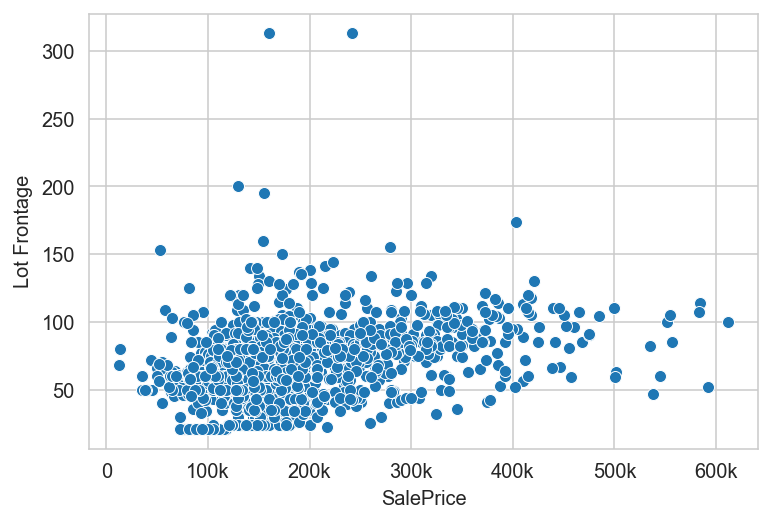

In [111]:
scatterplt(var='Lot Frontage')

_Outliers present:_

In [112]:
train_df.loc[train_df['Lot Frontage']>300, ['Lot Frontage']]

,Lot Frontage
960,313.0
1335,313.0


#### Lot Area distribution:

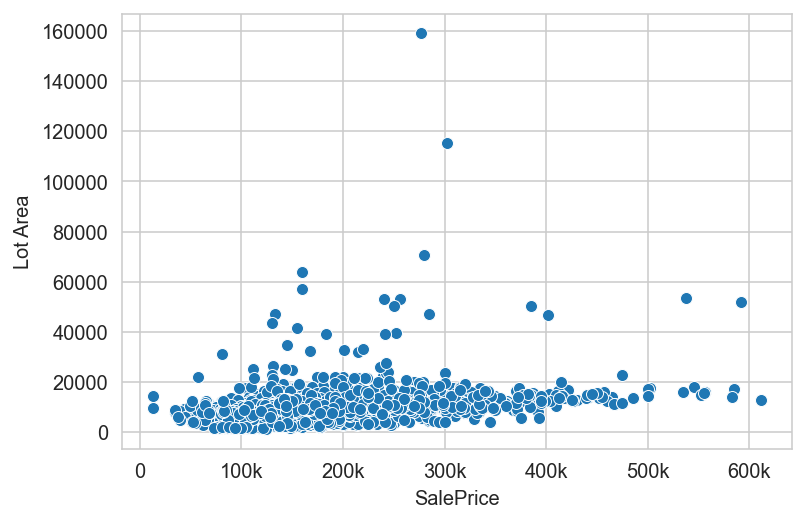

In [113]:
scatterplt(var='Lot Area')

_Outliers present:_

In [114]:
train_df.loc[train_df['Lot Area']>100000, ['Lot Area']]

,Lot Area
471,159000
694,115149


#### Year Built distribution:

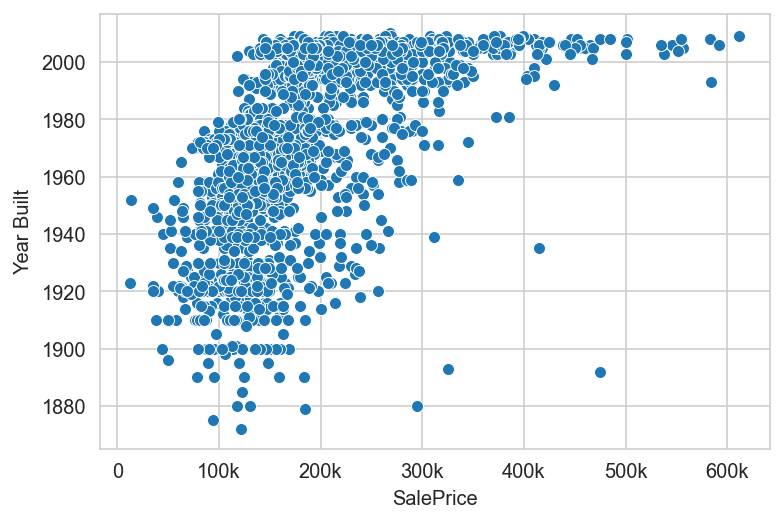

In [115]:
scatterplt(var='Year Built')

Appears to be an inverse exponential relationship between `Year Built` and `SalePrice`. Properties built before 2000 have a narrow range of `SalePrice`. While properties built after 2000 have a wide range of `SalePrice`.

_Outliers present:_

In [116]:
train_df.loc[(train_df['Year Built']<1936) & (train_df['SalePrice']>290000)]

,Id,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,SalePrice,have_bsmt,have_fireplace,have_garage,have_pool
1035,2667,902400110,75,R_others,90.0,22950,Pave,0,Irreg,Lvl,...,0,0,6,2006,WD,475000,1,1,1,0
1141,1321,902401120,75,R_others,75.0,13500,Pave,0,Reg,Lvl,...,0,0,7,2008,WD,325000,1,1,1,0
1897,2738,905427030,75,RL,60.0,19800,Pave,0,Reg,Lvl,...,0,0,12,2006,WD,415000,1,1,1,0
1939,1307,902207220,75,R_others,87.0,18386,Pave,0,Reg,Lvl,...,0,0,5,2008,WD,295000,1,1,1,0


#### Year Remod/Add distribution:

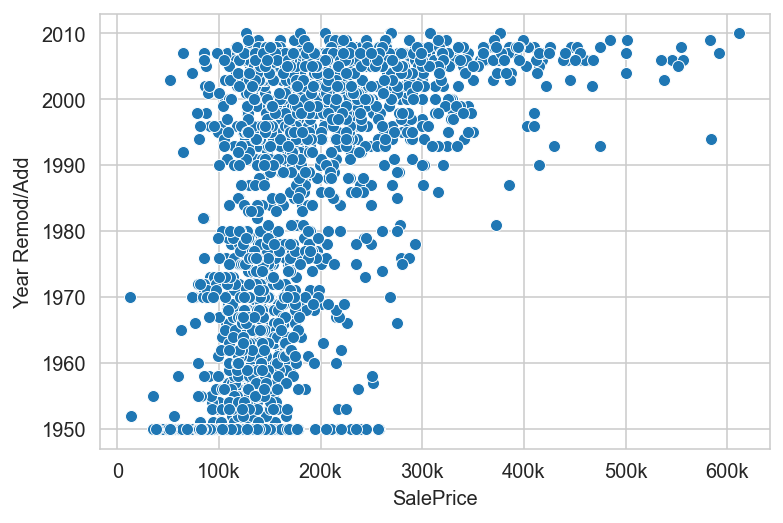

In [117]:
scatterplt(var='Year Remod/Add')

_No gross outliers._

#### Mas Vnr Area distribution:

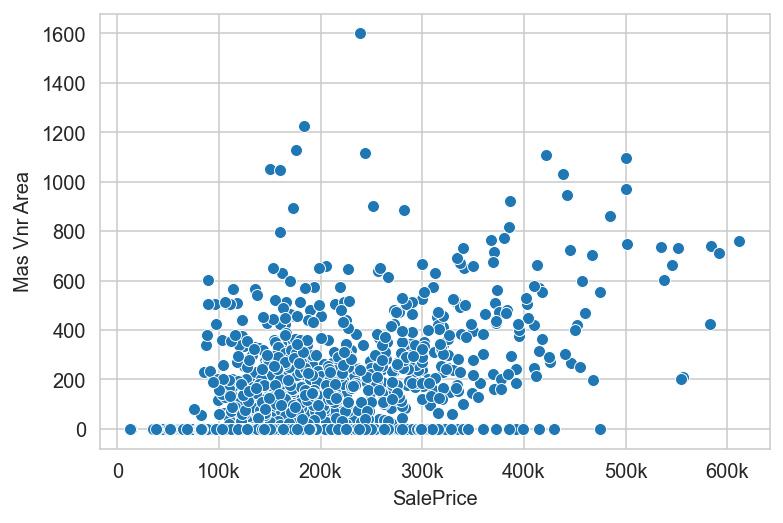

In [118]:
scatterplt(var='Mas Vnr Area')

_Outlier present:_

In [119]:
train_df.loc[(train_df['Mas Vnr Area']>1400), ['Mas Vnr Area']]

,Mas Vnr Area
1409,1600.0


#### BsmtFin SF 1 distribution:

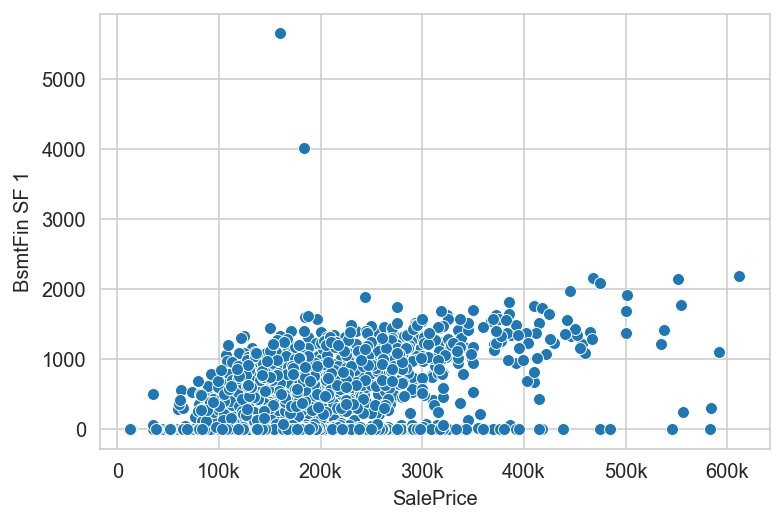

In [120]:
scatterplt(var='BsmtFin SF 1')

_Outliers present:_

In [121]:
train_df.loc[(train_df['BsmtFin SF 1']>3500), ['BsmtFin SF 1']]

,BsmtFin SF 1
960,5644.0
1885,4010.0


#### BsmtFin SF 2 distribution:

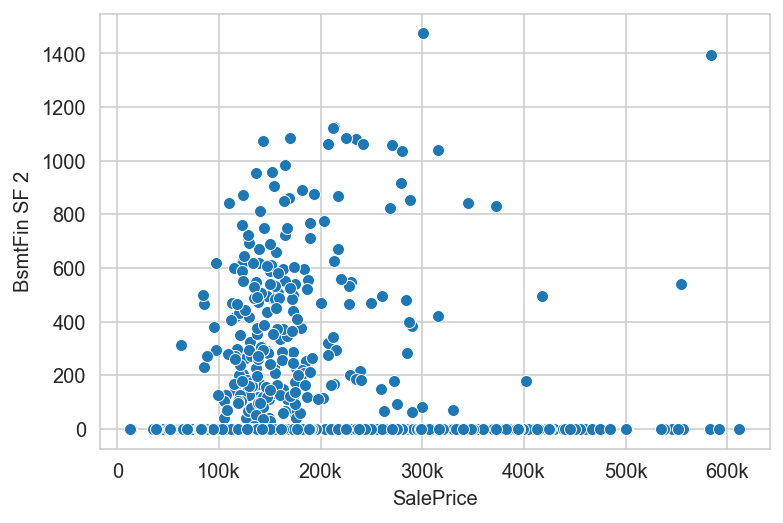

In [122]:
scatterplt(var='BsmtFin SF 2')

_Outliers present:_

In [123]:
train_df.loc[(train_df['BsmtFin SF 2']>1200), ['BsmtFin SF 2']]

,BsmtFin SF 2
770,1474.0
1692,1393.0


Based on the 2 scatterplots above, the distributions of `BsmtFin SF 1` and `BsmtFin SF 2` have poor value in determining `SalePrice`. I will consider these 2 features to have low predictive value for `SalePrice`.

#### Bsmt Unf SF distribution:

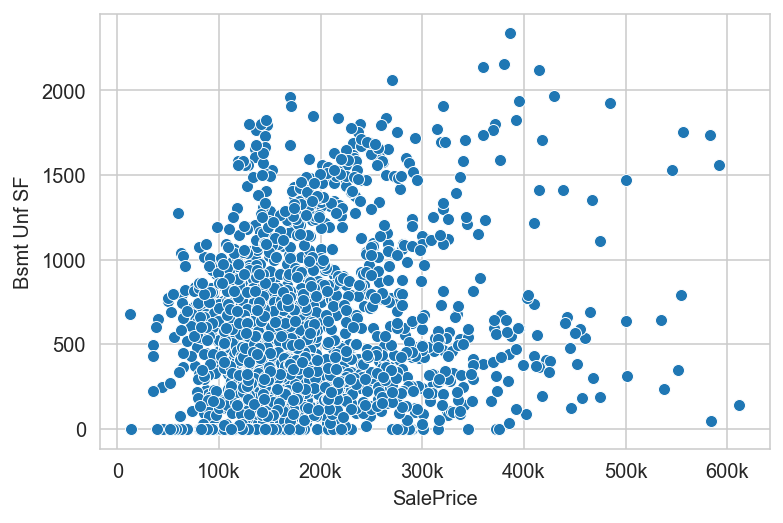

In [124]:
scatterplt(var='Bsmt Unf SF')

_No gross outliers._

#### Total Bsmt SF distribution:

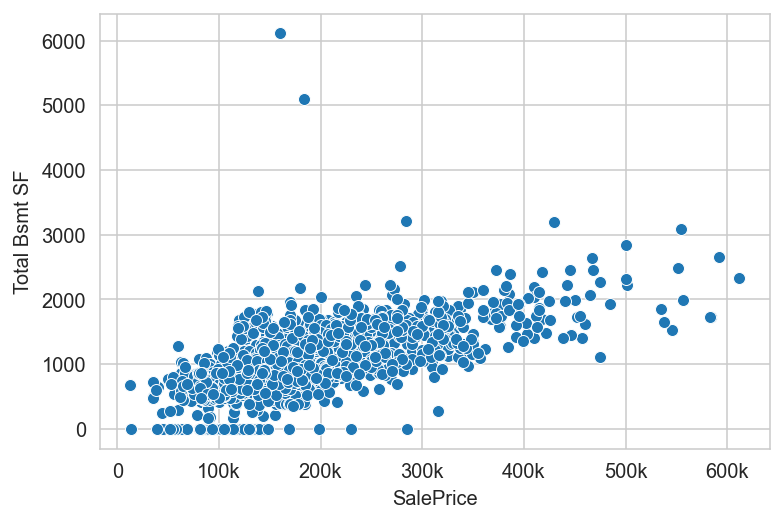

In [125]:
scatterplt(var='Total Bsmt SF')

_Outliers present:_

In [126]:
train_df.loc[(train_df['Total Bsmt SF']>5000), ['Total Bsmt SF']]

,Total Bsmt SF
960,6110.0
1885,5095.0


#### 1st Flr SF distribution:

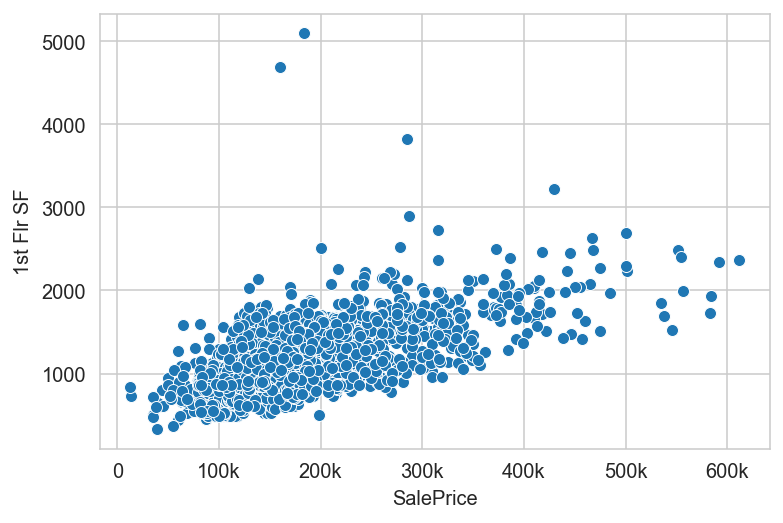

In [127]:
scatterplt(var='1st Flr SF')

_Outliers present:_

In [128]:
train_df.loc[(train_df['1st Flr SF']>4000), ['1st Flr SF']]

,1st Flr SF
960,4692
1885,5095


#### 2nd Flr SF distribution:

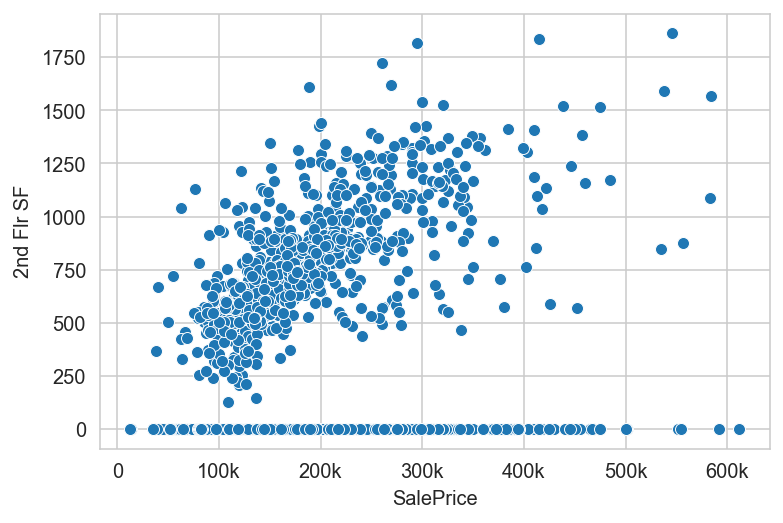

In [129]:
scatterplt(var='2nd Flr SF')

_No gross outliers._

Based on the spread of data points for `2nd Flr SF` feature, with lots of '0's spread across the entire range of `SalePrice`, I will consider this feature having low predictive value for `SalePrice`.

#### Low Qual Fin SF:

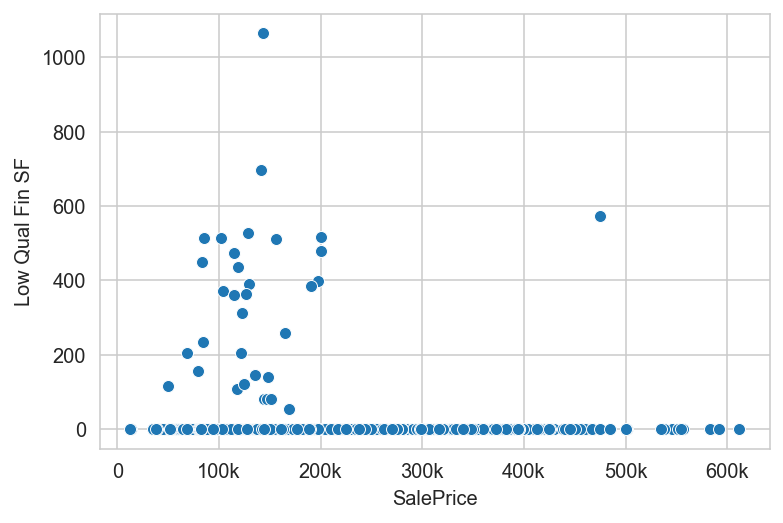

In [130]:
scatterplt(var='Low Qual Fin SF')

_Outliers present:_

In [131]:
train_df.loc[(train_df['Low Qual Fin SF']>1000) | 
             ((train_df['Low Qual Fin SF']>500)&(train_df['SalePrice']>400000)), 
             ['Low Qual Fin SF','SalePrice']]

,Low Qual Fin SF,SalePrice
828,1064,142900
1035,572,475000


Based on the spread of data points for `Low Qual Fin SF` feature, with lots of '0's spread across the entire range of `SalePrice`, I will consider this feature to have low predictive value for `SalePrice`.

#### Gr Liv Area distribution:

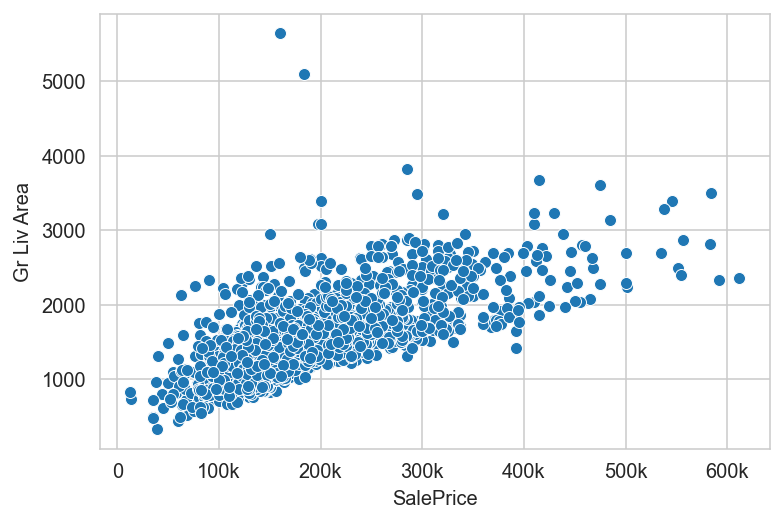

In [132]:
scatterplt(var='Gr Liv Area')

_Outliers present:_

In [133]:
train_df.loc[(train_df['Gr Liv Area']>4000), ['Gr Liv Area']]

,Gr Liv Area
960,5642
1885,5095


#### Bsmt Full Bath distribution:

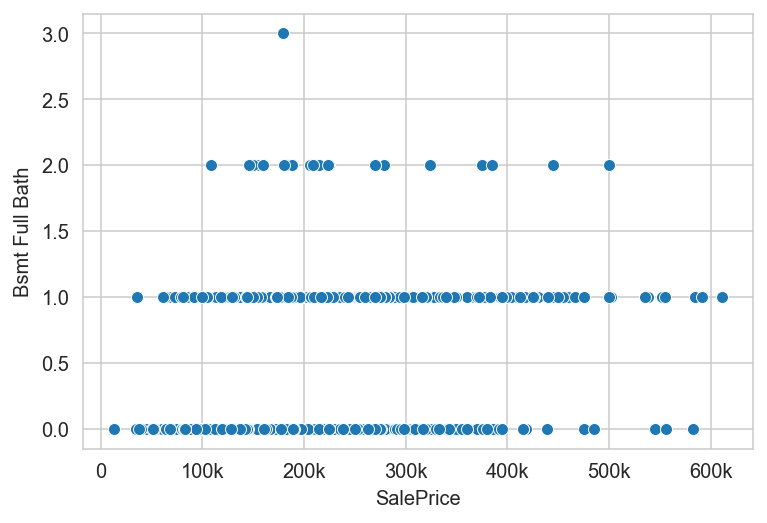

In [134]:
scatterplt(var='Bsmt Full Bath')

Based on the spread of data points for `Bsmt Full Bath` feature, with lots of '0's spread across the entire range of `SalePrice`, and no discernible pattern to `SalePrice`, I will consider this feature to have low predictive value for `SalePrice`.

#### Bsmt Half Bath distribution:

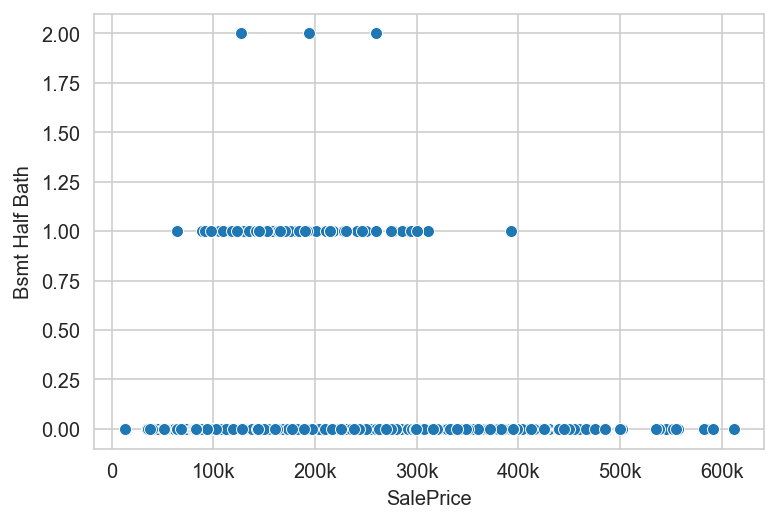

In [135]:
scatterplt(var='Bsmt Half Bath')

Based on the spread of data points for `Bsmt Half Bath` feature, with lots of '0's spread across the entire range of `SalePrice`, I will consider this feature to have low predictive value for `SalePrice`.

#### Full Bath distribution:

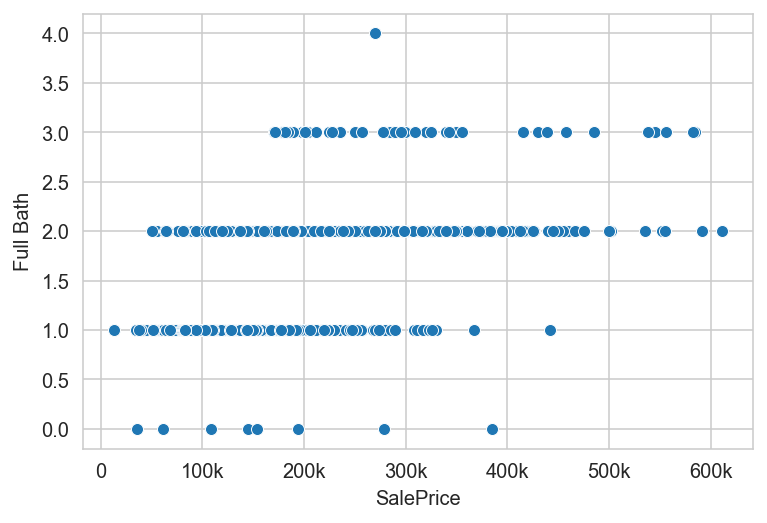

In [136]:
scatterplt(var='Full Bath')

_Outliers present:_

In [137]:
train_df.loc[(train_df['Full Bath']==4), ['Full Bath','SalePrice']]

,Full Bath,SalePrice
1566,4,269500
1605,4,269500


#### Half Bath distribution:

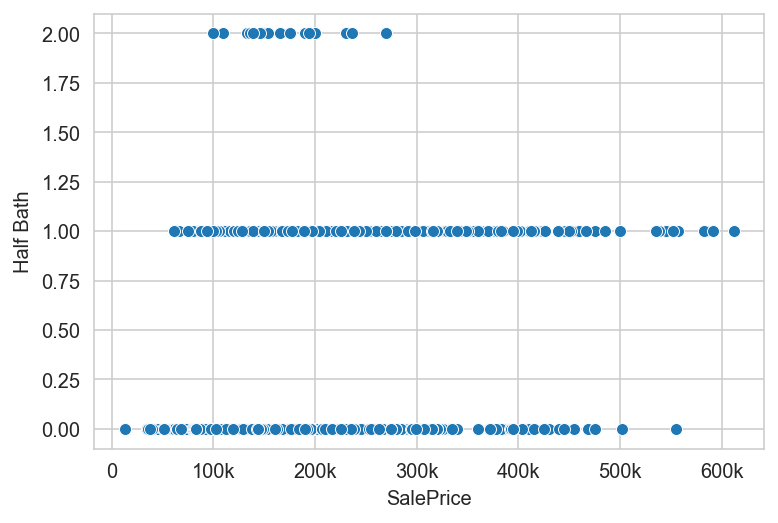

In [138]:
scatterplt(var='Half Bath')

Based on the spread of data points for `Half Bath` feature, with lots of '0's spread across the entire range of `SalePrice` and no discernible pattern with `SalePrice`, I will consider this feature of low predictive value for `SalePrice`.

#### Bedroom AbvGr distribution:

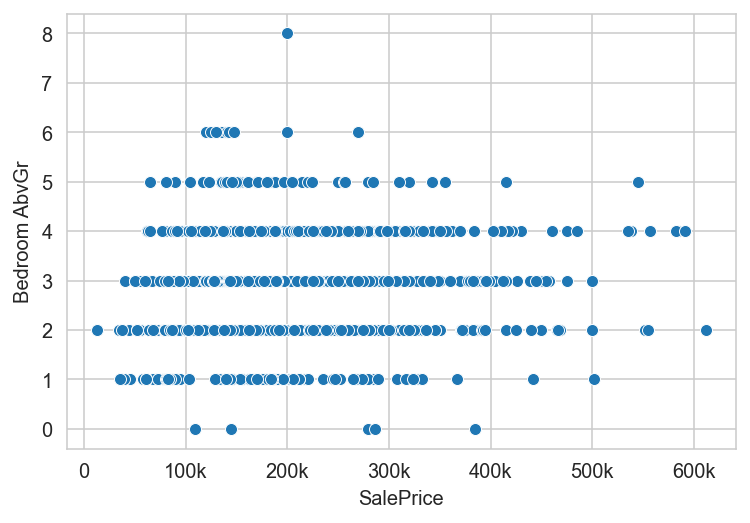

In [139]:
scatterplt(var='Bedroom AbvGr')

Based on the spread of data points for `Bedroom AbvGr` feature, with no discernable relationship with `SalePrice`, I will consider this feature of low predictive value for `SalePrice`.

#### Kitchen AbvGr distribution:

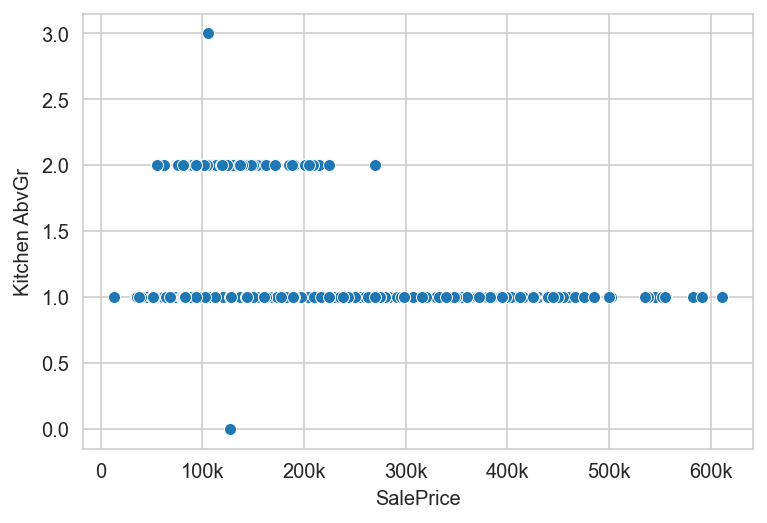

In [140]:
scatterplt(var='Kitchen AbvGr')

Based on the spread of data points for `Kitchen AbvGr` feature, with no discernable relationship with `SalePrice`, I will consider this feature of low predictive value for `SalePrice`.

#### TotRms AbvGrd distribution: 

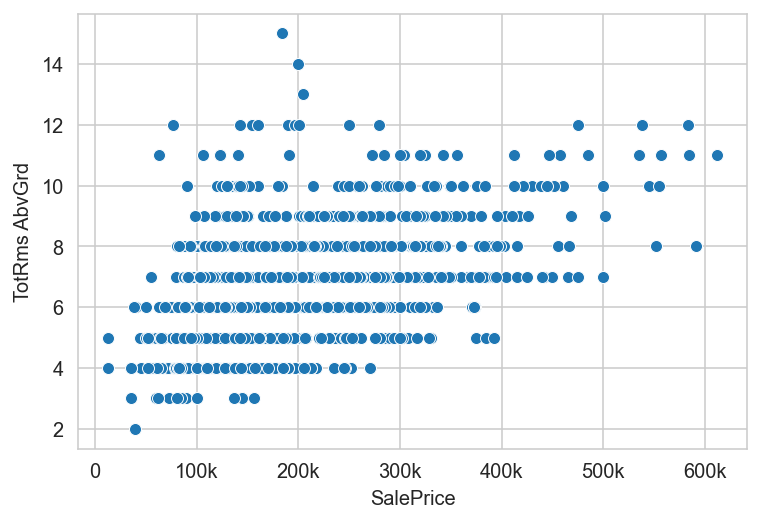

In [141]:
scatterplt(var='TotRms AbvGrd')

_Outliers present:_

In [142]:
train_df.loc[(train_df['TotRms AbvGrd']>12), ['TotRms AbvGrd']]

,TotRms AbvGrd
858,14
1791,13
1885,15


#### Fireplaces distribution:

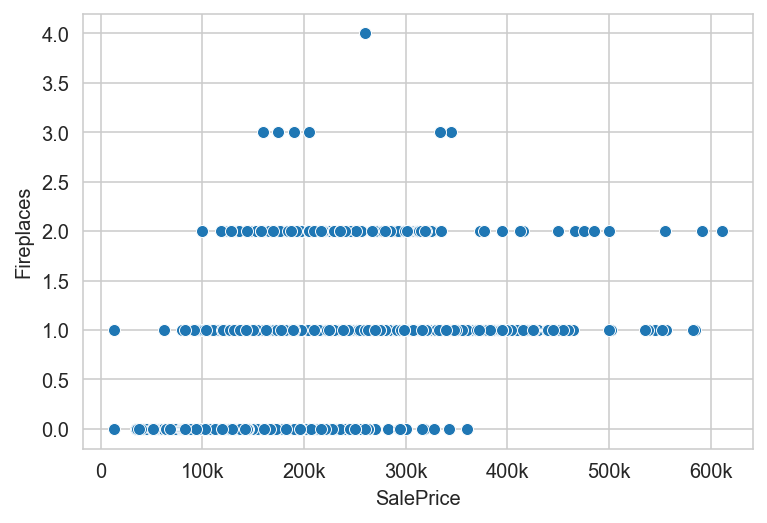

In [143]:
scatterplt(var='Fireplaces')

No gross outliers. There is weak positive correlation between 0 and 2 `Fireplaces` and `SalePrice`.

#### Garage Cars distribution:

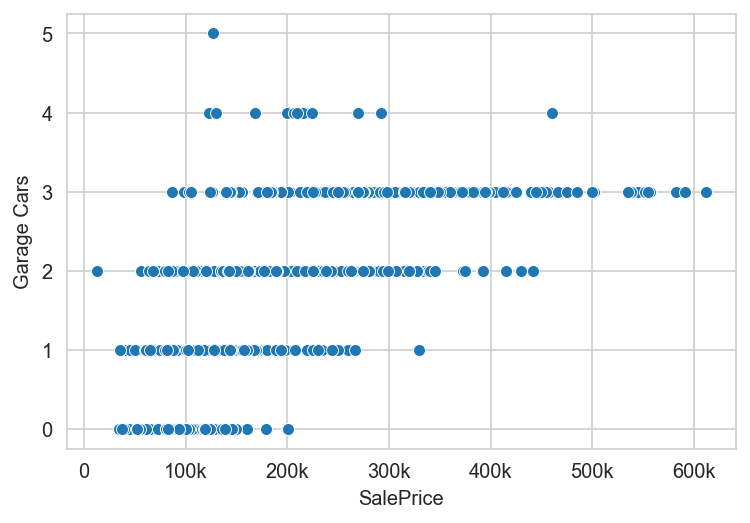

In [144]:
scatterplt(var='Garage Cars')

No gross outliers. There is weak positive correlation between 0 and 3 `Garage Cars` and `SalePrice`.

#### Garage Area distribution:

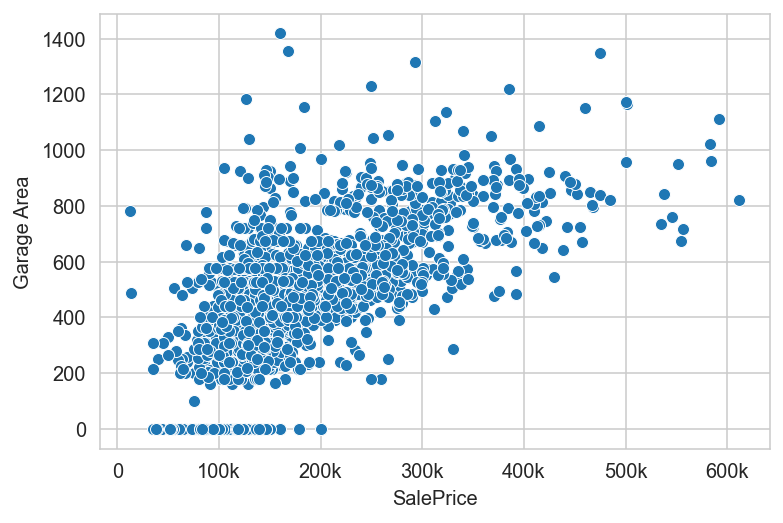

In [145]:
scatterplt(var='Garage Area')

_No gross outliers._

#### Wood Deck SF distribution:

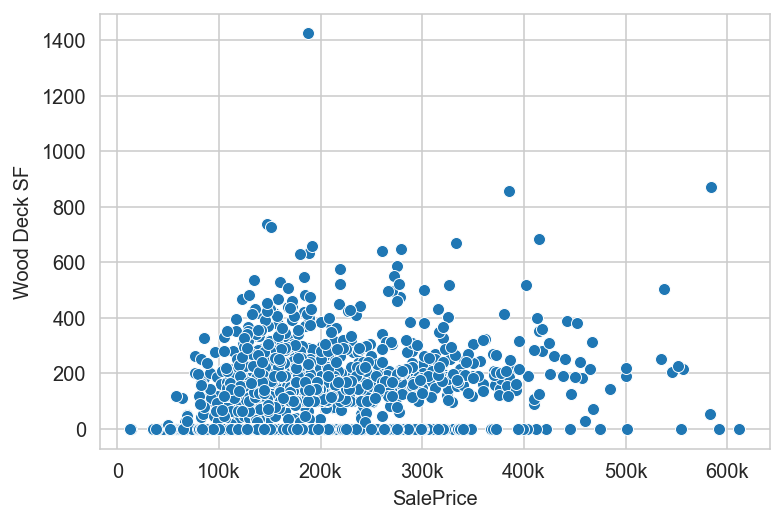

In [146]:
scatterplt(var='Wood Deck SF')

_Outlier present:_

In [147]:
train_df.loc[(train_df['Wood Deck SF']>1400), ['Wood Deck SF']]

,Wood Deck SF
966,1424


#### Open Porch SF distribution:

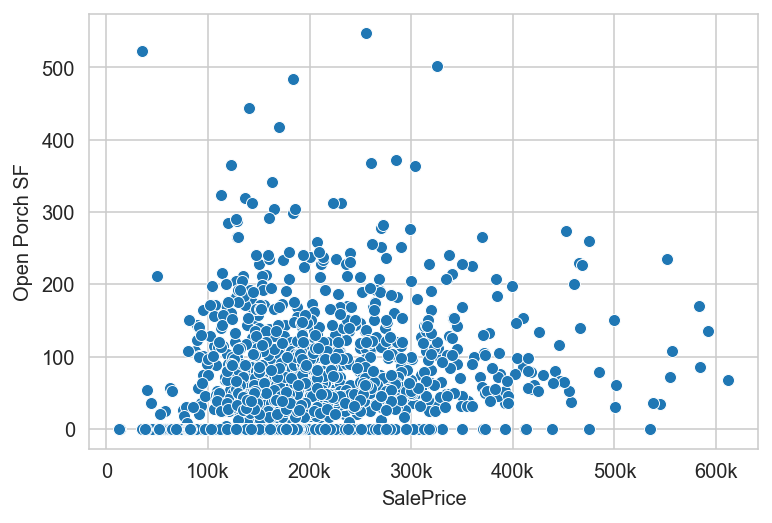

In [148]:
scatterplt(var='Open Porch SF')

_No gross outliers._

#### Enclosed Porch distribution:

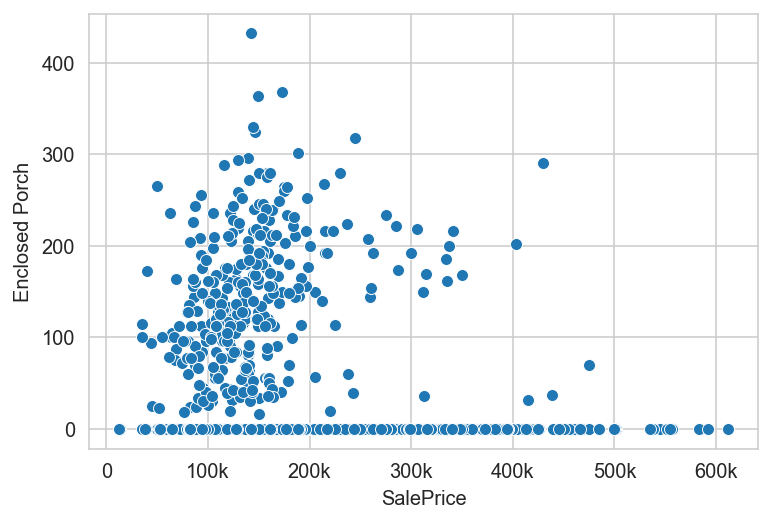

In [149]:
scatterplt(var='Enclosed Porch')

_No gross outliers._

#### 3Ssn Porch distribution:

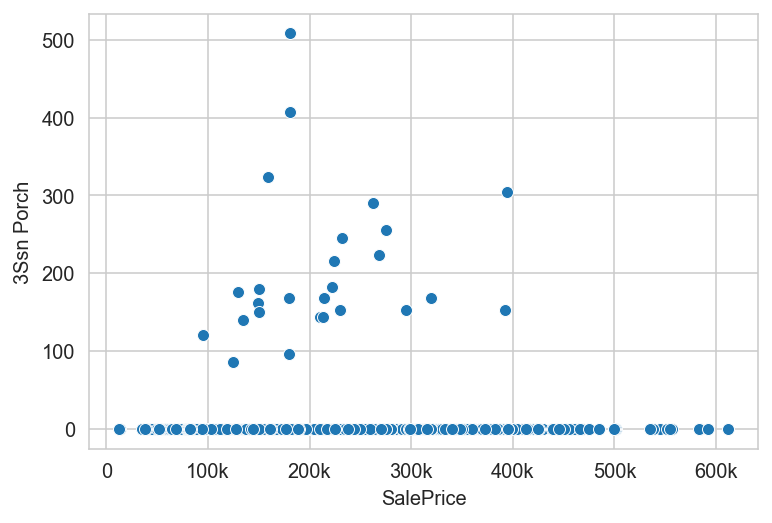

In [150]:
scatterplt(var='3Ssn Porch')

Based on the spread of data points for `3Ssn Porch` feature, with a lot of '0's, I will consider this feature to have low predictive value for `SalePrice`.

#### Screen Porch distribution:

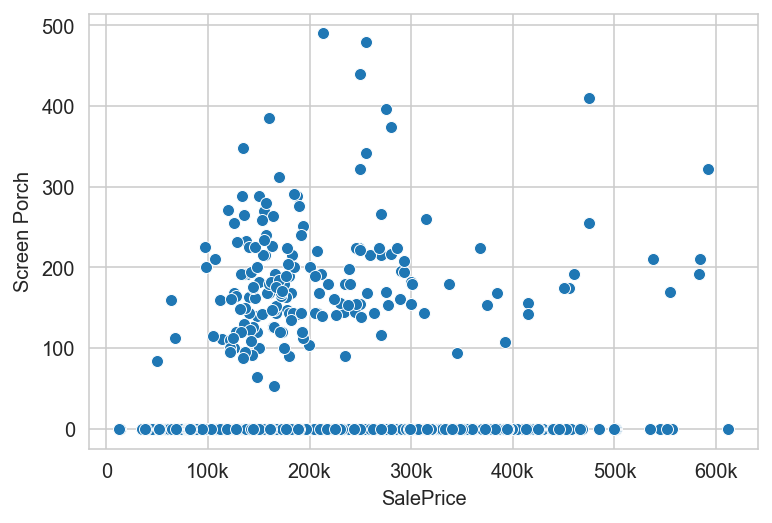

In [151]:
scatterplt(var='Screen Porch')

_No gross outliers._

#### Pool Area distribution:

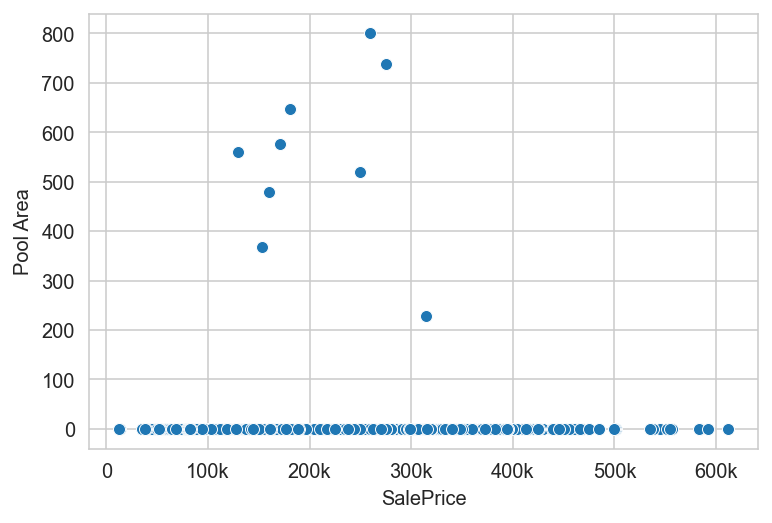

In [152]:
scatterplt(var='Pool Area')

Based on the spread of data points for `Pool Area` feature, with a lot of '0's, I will consider this feature to have low predictive value for `SalePrice`.

#### Misc Val distribution:

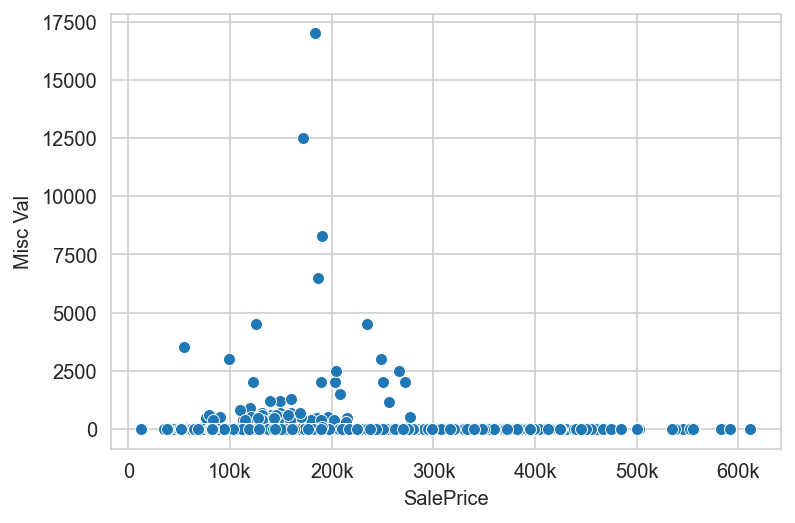

In [153]:
scatterplt(var='Misc Val')

Based on the spread of data points for `Misc Val` feature, with a lot of '0's, I will consider this feature to have low predictive value for `SalePrice`.

#### Mo Sold distribution:

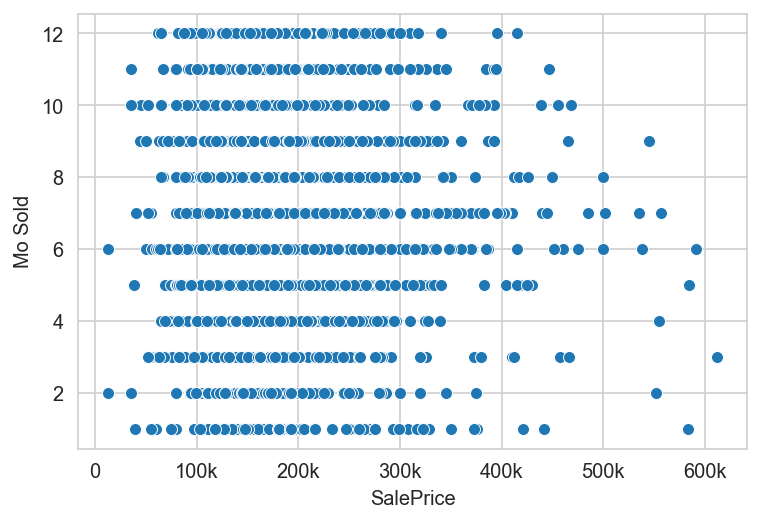

In [154]:
scatterplt(var='Mo Sold')

_No gross outliers._

#### Yr Sold distribution:

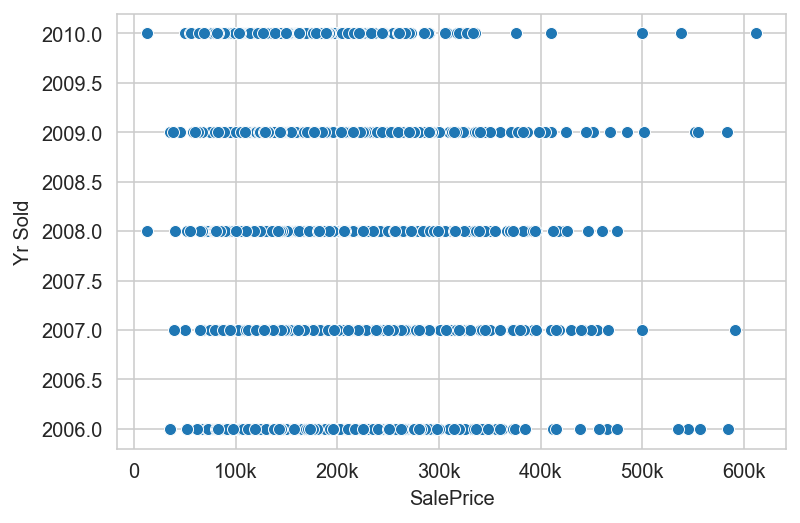

In [155]:
scatterplt(var='Yr Sold')

_No gross outliers._

#### SalePrice distribution:

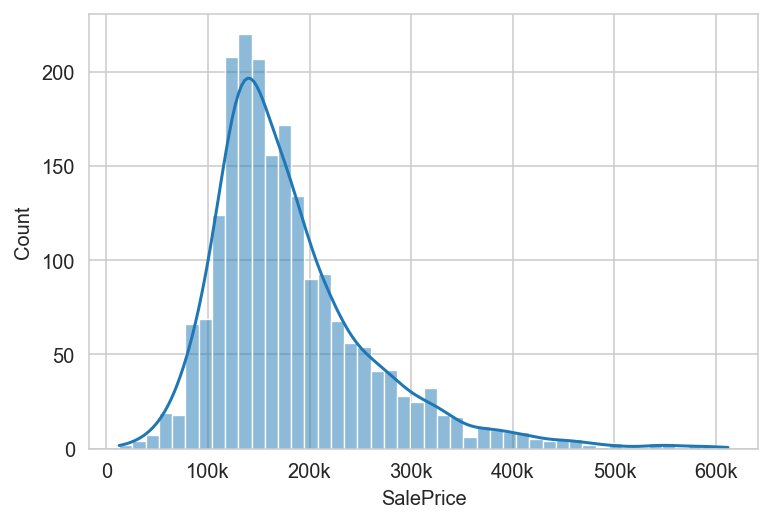

In [158]:
sns.histplot(data=train_df, x='SalePrice', kde=True)
plt.xticks([0,100000,200000,300000,400000,500000,600000],
               [0,'100k','200k','300k','400k','500k','600k']);

Right skewed distribution for `SalePrice`. Most properties had a `SalePrice` between 100k and 250k. While the highest `SalePrice` is about 600k.

##### Outliers identified via scatterplots in EDA:

In [159]:
print(drop_set.intersection(set(outlier_list))) 
# comparing with drop_set that involved dropping rows with multiple null values 

set()


These outliers are **not the same datapoints** with missing values that were dropped in `train_drop` data.

#### train_df1

Final dataframe before feeding to model.

In [160]:
train_drop.shape

(2026, 148)

In [161]:
# drop outliers identified from scatterplots
train_df1 = train_drop.drop(index=outlier_list)

In [162]:
train_df1.shape

(2012, 148)

## Feature selection based on correlation with `SalePrice`
---

__Contents:__
1. [Correlation series based on `SalePrice`](#corr_mat)
1. Statistical significance of correlation
    * [Part One](#Statistical-significance-of-correlation:)
    * [Part Two](#Statistical-significance-of-correlation-(cont'd):)

##### corr_mat

In [163]:
# correlation list in relation to SalePrice
corr_mat = train_df1.corr().SalePrice.sort_values(ascending=False)
corr_mat.head(20)

SalePrice         1.000000
Overall Qual      0.805464
Exter Qual        0.721990
Gr Liv Area       0.715639
Kitchen Qual      0.692262
Total Bsmt SF     0.671040
1st Flr SF        0.653550
Garage Area       0.651454
Garage Cars       0.649119
Bsmt Qual         0.624178
Year Built        0.594510
Garage Finish     0.570501
Year Remod/Add    0.553332
fdn_PConc         0.543533
Fireplace Qu      0.538333
Full Bath         0.532908
Mas Vnr Area      0.529145
TotRms AbvGrd     0.504563
grge_t_Attchd     0.484356
have_fireplace    0.483949
Name: SalePrice, dtype: float64

In [164]:
# function to distill out the features based on high correlation with `SalePrice`
def corr_list(series, threshold):
    lst = []
    for index, value in series.items():
        if value > threshold:
            lst.append(index)
            
    for item in lst:
        if item == 'SalePrice':
            lst.remove(item)
    return lst

In [165]:
corr_05 = corr_list(corr_mat, threshold=0.5)

In [166]:
len(corr_05)

17

I decided to use 0.5 as a correlation threshold to select features that are strongly related to `SalePrice`. This also results in a manageable number of features to fit into my model. There have been other ways of feature selection I have tried (e.g. Lasso model, variation inflation factor scores) but this one seems to result in the best performing model for me. 

##### Statistical significance of correlation:

[Correlation reference](https://stackoverflow.com/questions/41075098/how-to-get-the-p-value-in-a-variable-from-olsresults-in-python)

In [167]:
# calling function to make a list of features from the above correlation pd.Series
# using 0.3 correlation strength as a threshold to include more features for testing
# some strongly correlated features with `SalePrice` may not be statistically significant
corr_03 = corr_list(corr_mat, threshold=0.3)

In [168]:
# need to test for statistical significance
X = train_df1[corr_03]
y = train_df1['SalePrice']

In [169]:
X.isnull().sum().sort_values(ascending=False)[:3] 
# X has null values that OLS model cannot accept

Lot Frontage    321
Overall Qual      0
Exter Qual        0
dtype: int64

When I attempted to perform the test for statistical signficance of the correlation between features and `SalePrice`, the test threw an error that X still have null values that needed to be dealt with. So I had to put this test aside until I performed the train-test-split, which is the next step.

## Train-test-split:
---

In [170]:
# import modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [171]:
# Create X and y
'''
I would also drop `Id` and `PID` features since they seem to be just serial numbers, 
and are not meaningful in real world setting for predicting sale price
'''
X = train_df1.drop(columns=['SalePrice','Id','PID'])
y = train_df1['SalePrice']

In [172]:
# create train-test-split sets
# since this is not a classification problem, y cannot be stratified
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [173]:
# check X_train for null values, since `Lot Frontage` is not yet imputed
X_train.isnull().sum().sort_values(ascending=False)[:3]

Lot Frontage      219
hse_s_split         0
nbrhd_pc_50014      0
dtype: int64

## Imputation of train set:
---

KNN imputation will impute all missing values in a dataframe. <br><br>
I have ensured that all other null values in other features have been dealt with, leaving only `Lot Frontage` to be imputed as I wish to keep imputation at the minimum. Sometimes imputed data can exaggerate any bias already present.<br><br>
`Lot Frontage` has a sizable portion of missing values that makes dropping rows sacrificing sizable amount of limited data, but yet not sizable enough (< 50%) that would make imputation impossible or likely inaccurate.<br><br> 

### imp_X_train

In [174]:
# import imputer from sklearn module
from sklearn.impute import KNNImputer

In [175]:
# instantiate imputer
imp = KNNImputer()

In [176]:
'''
fit only X_train, transform both X_train and X_test
create new dataframe variable with the imputed `Lot Frontage` values
'''
imp_X_train = imp.fit_transform(X_train)
imp_X_test = imp.transform(X_test)

In [178]:
imp_X_train = pd.DataFrame(imp_X_train, columns=X_train.columns)
imp_X_test = pd.DataFrame(imp_X_test, columns=X_test.columns)

In [179]:
# no null values left after imputation
print(' imp_X_train '.center(18, "="))
print(imp_X_train.isnull().sum().sort_values(ascending=False)[:3])
print()
print(' imp_X_test '.center(18, '='))
print(imp_X_test.isnull().sum().sort_values(ascending=False)[:3])

== imp_X_train ===
MS SubClass    0
msz_RL         0
nbrhd_nan      0
dtype: int64

=== imp_X_test ===
MS SubClass    0
msz_RL         0
nbrhd_nan      0
dtype: int64


##### Statistical significance of correlation (cont'd):

Now that missing values in `Lot Frontage` has been imputed, I will join the `imp_X_train` with `y_train` into a new dataframe to calculate the statistical significance of correlation between features and `SalePrice`.

In [180]:
imp_X_train.shape

(1408, 145)

In [181]:
imp_X_train.head(3)

,MS SubClass,Lot Frontage,Lot Area,Alley,Utilities,Land Slope,Overall Qual,Overall Cond,Year Built,Year Remod/Add,...,elec_SBrkr,elec_other,elec_nan,pvdr_Y,pvdr_other,pvdr_nan,sle_t_Con,sle_t_Oth,sle_t_WD,sle_t_nan
0,80.0,96.0,11777.0,0.0,4.0,3.0,5.0,6.0,1966.0,1966.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,20.0,104.0,14418.0,0.0,4.0,3.0,9.0,5.0,2007.0,2007.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,60.0,108.0,14774.0,0.0,4.0,3.0,9.0,5.0,1999.0,1999.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [182]:
y_train.shape

(1408,)

In [183]:
y_train.head(3) 
# notice that y_train indices are not the same as imp_X_train

566     164500
1084    383000
1909    333168
Name: SalePrice, dtype: int64

In [184]:
y_train.reset_index(drop=True, inplace=True) 
# reseting y_train indices to match imp_X_train, so that concat is done correctly

In [185]:
# join imp_X_train with y_train to get dataframe to draw correlation
train_set = pd.concat([imp_X_train,y_train], axis=1)

In [186]:
train_set.shape

(1408, 146)

In [187]:
corr_mat2 = train_set.corr().SalePrice.sort_values(ascending=False)
corr_mat2.head(20) 
# notice there is a slight change in rankings after splitting of data,
# and imputation, but not by alot

SalePrice         1.000000
Overall Qual      0.803727
Exter Qual        0.727130
Gr Liv Area       0.707312
Kitchen Qual      0.683617
Total Bsmt SF     0.672971
1st Flr SF        0.650016
Garage Area       0.645257
Garage Cars       0.643094
Bsmt Qual         0.620127
Year Built        0.596637
Garage Finish     0.564023
Year Remod/Add    0.556386
Full Bath         0.539955
Fireplace Qu      0.536226
fdn_PConc         0.535120
Mas Vnr Area      0.523031
TotRms AbvGrd     0.484751
have_fireplace    0.481908
BsmtFin SF 1      0.480425
Name: SalePrice, dtype: float64

In [188]:
print(corr_03)

['Overall Qual', 'Exter Qual', 'Gr Liv Area', 'Kitchen Qual', 'Total Bsmt SF', '1st Flr SF', 'Garage Area', 'Garage Cars', 'Bsmt Qual', 'Year Built', 'Garage Finish', 'Year Remod/Add', 'fdn_PConc', 'Fireplace Qu', 'Full Bath', 'Mas Vnr Area', 'TotRms AbvGrd', 'grge_t_Attchd', 'have_fireplace', 'bsmtf_t1_GLQ', 'Fireplaces', 'Heating QC', 'BsmtFin SF 1', 'Bsmt Exposure', 'Lot Frontage', 'ex_1_VinylSd', 'ex_2_VinylSd', 'Lot Area', 'Open Porch SF', 'Wood Deck SF', 'mvt_Stone', 'lt_s_Irreg']


In [189]:
# testing for statistical significance
X = train_set[corr_03]
y = train_set['SalePrice']

X = sm.add_constant(X, prepend=True)
model_ols = sm.OLS(y, X).fit()

d = {}
for i in X.columns.tolist():
    d[f'{i}'] = model_ols.pvalues[i]

df_pvalue= pd.DataFrame(d.items(), columns=['var_name', 'p-value']).sort_values(by = 'p-value').reset_index(drop=True)

In [190]:
df_pvalue.head(19)

,var_name,p-value
0,Overall Qual,8.083564e-33
1,BsmtFin SF 1,9.029138e-32
2,Gr Liv Area,4.241665e-30
3,Lot Area,1.551480e-16
4,Exter Qual,8.872224e-16
5,const,1.583548e-10
6,Kitchen Qual,5.590670e-07
7,Mas Vnr Area,4.778446e-06
8,Bsmt Exposure,5.868639e-06
9,mvt_Stone,2.056502e-05


In [191]:
'''
constructed function to distill the features that
had statistically significant correlation with `SalePrice` i.e p-value <0.05
''' 
def pvalue_list(df):
    lst = []
    for feature, pvalue in zip(df['var_name'],df['p-value']):
        if pvalue < 0.05:
            lst.append(feature)
    for item in lst:
        if item == 'const':
            lst.remove(item)
    return lst

In [192]:
print(pvalue_list(df_pvalue))

['Overall Qual', 'BsmtFin SF 1', 'Gr Liv Area', 'Lot Area', 'Exter Qual', 'Kitchen Qual', 'Mas Vnr Area', 'Bsmt Exposure', 'mvt_Stone', 'Fireplace Qu', 'Year Remod/Add', 'Garage Area', 'Year Built', 'Total Bsmt SF', 'have_fireplace', 'Full Bath', 'fdn_PConc']


In [193]:
len(pvalue_list(df_pvalue))

17

Using this method for feature selection also resulted in 17 features. I used these features to feed my model and resulted in a better performing model than the 17 features from `corr_05`. However, the difference in RMSE performance between train and test sets became wider. The model became overfitted on training data. So I decided to stick with using the 17 features from `corr_05` for my model.

## Processed Dataframes: 
---

* [Train Data](#train_df)
* [Dummified Train Data](#train_dum)
* [Dropped rows Train Data](#train_drop)
* [No outliers Train Data](#train_df1)
* [Imputed `Lot Frontage` train-set data](#imp_X_train)

## GridSearch CV
---

[GridSearch + Pipeline multiple models reference](https://ryan-reilly.medium.com/gridsearch-pipelines-of-multiple-models-on-multiclass-classification-e9124b6ea2e3)

_**Isolate columns desired in X_train**_

In [194]:
X_train_17 = imp_X_train[corr_05]
X_test_17 = imp_X_test[corr_05]

_**Checking range of values for each feature selected for model**_

In [195]:
X_train_17.describe().T

,count,mean,std,min,25%,50%,75%,max
Overall Qual,1408.0,6.077415,1.405786,1.0,5.00,6.0,7.00,10.0
Exter Qual,1408.0,3.387074,0.579221,2.0,3.00,3.0,4.00,5.0
Gr Liv Area,1408.0,1470.638494,466.630961,480.0,1120.75,1427.5,1717.00,3395.0
Kitchen Qual,1408.0,3.497869,0.668083,2.0,3.00,3.0,4.00,5.0
Total Bsmt SF,1408.0,1037.991477,420.088972,0.0,780.00,986.5,1297.25,3200.0
1st Flr SF,1408.0,1144.625000,367.885516,372.0,872.00,1080.5,1370.00,3228.0
Garage Area,1408.0,468.729403,210.373989,0.0,313.00,478.0,576.00,1348.0
Garage Cars,1408.0,1.759943,0.752565,0.0,1.00,2.0,2.00,4.0
Bsmt Qual,1408.0,3.461648,0.897730,0.0,3.00,3.0,4.00,5.0
Year Built,1408.0,1971.400568,30.113739,1872.0,1953.00,1974.0,2000.00,2009.0


_**Instantiate Pipeline for GridSearchCV, built-in standardisation**_

In [196]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

In [197]:
# Instantiate a StandardScaler + LR pipeline.
pipe1 = Pipeline([
    ('ss', StandardScaler()),
    ('lr', LinearRegression())
])

# Instantiate a StandardScaler + Ridge pipeline.
pipe2 = Pipeline([
    ('ss', StandardScaler()),
    ('ridge', Ridge())
])

# Instantiate a StandardScaler + LASSO pipeline.
pipe3 = Pipeline([
    ('ss', StandardScaler()),
    ('lasso', Lasso())
])

# Instantiate a StandardScaler + ElasticNet pipeline.
pipe4 = Pipeline([
    ('ss', StandardScaler()),
    ('enet', ElasticNet())
])

In [198]:
# Create dictionary of hyperparameters.
enet_ratio = [.5,.8,.9,.95]
n_neighbors = [3,5,10]
alpha_l = [1.,10.,100.,500.,1000.]

pipe1_params = {'lr__fit_intercept': [True, False],
                'lr__positive': [True, False]
               }

pipe2_params = {'ridge__alpha': alpha_l
               }

pipe3_params = {'lasso__alpha': alpha_l,
                'lasso__max_iter': [10000, 50000]
               }

pipe4_params = {'enet__alpha': alpha_l,
                'enet__l1_ratio': enet_ratio
               }

_**Instantiate GridSearchCV**_

In [199]:
from sklearn.model_selection import GridSearchCV

In [200]:
cv_ct = 5
score = 'neg_root_mean_squared_error'

pipe1_gs = GridSearchCV(pipe1,
                       pipe1_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

pipe2_gs = GridSearchCV(pipe2,
                       pipe2_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

pipe3_gs = GridSearchCV(pipe3,
                       pipe3_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

pipe4_gs = GridSearchCV(pipe4,
                       pipe4_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

_**Fit models from GridSearchCV pipeline**_

In [201]:
# combine the grids to loop through
grids = [pipe1_gs, pipe2_gs, pipe3_gs, pipe4_gs]

for pipe in grids:
    pipe.fit(X_train_17,y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


_**Evaluate models**_

In [202]:
from sklearn.metrics import mean_squared_error

In [203]:
y_bar = np.repeat(np.mean(y_train),(len(y_train)))
y_bar_rmse = mean_squared_error(y_train, y_bar, squared=False)

grid_dict = {0: 'Linear regression', 1: 'Ridge regression',
            2: 'Lasso regression', 3: 'ElasticNet regression'}

for i, model in enumerate(grids):
    print(f'y_bar rmse: {y_bar_rmse}')
    print(f'{grid_dict[i]} train rmse: {model.score(X_train_17, y_train)}')
    print(f'{grid_dict[i]} test rmse: {model.score(X_test_17, y_test)}')
    print(f'{grid_dict[i]} %_diff rmse: {((model.score(X_train_17, y_train)-model.score(X_test_17, y_test))*100)/model.score(X_train_17, y_train)} %')
    print(f'{grid_dict[i]} Best Params: {model.best_params_}')
    print()

y_bar rmse: 77440.56492336537
Linear regression train rmse: -29109.18123636679
Linear regression test rmse: -29955.79402575675
Linear regression %_diff rmse: -2.9084046800061407 %
Linear regression Best Params: {'lr__fit_intercept': True, 'lr__positive': False}

y_bar rmse: 77440.56492336537
Ridge regression train rmse: -29111.550486959437
Ridge regression test rmse: -29950.720856231568
Ridge regression %_diff rmse: -2.8826027993529197 %
Ridge regression Best Params: {'ridge__alpha': 10.0}

y_bar rmse: 77440.56492336537
Lasso regression train rmse: -29114.816912084447
Lasso regression test rmse: -29920.16348735268
Lasso regression %_diff rmse: -2.766105580193303 %
Lasso regression Best Params: {'lasso__alpha': 100.0, 'lasso__max_iter': 10000}

y_bar rmse: 77440.56492336537
ElasticNet regression train rmse: -29182.89006953915
ElasticNet regression test rmse: -29981.152833523025
ElasticNet regression %_diff rmse: -2.735379402388578 %
ElasticNet regression Best Params: {'enet__alpha': 1.0

All my models via GridSearchCV are performing better than baseline despite poor absolute `RMSE` scores. Since the `% diff` values do not differ significantly between the various linear model types, I will choose the model with the **best test rmse** for making predictions on the [test.csv](./datasets/test.csv). That would be the **Lasso model**.

## LassoCV
---

_**Fine tuning Lasso model**_

In [204]:
from sklearn.linear_model import LassoCV

_**Construct LASSO instantiate function**_

In [205]:
def lasso_cv(train, test):
    ss = StandardScaler()  # standardise X_train, X_test
    Z_train = ss.fit_transform(train)
    Z_test = ss.transform(test) 
    
    ######## Lasso cv model ########
    l_alphas = np.linspace(50, 150, 100) # list of alphas to check
    lasso_cv = LassoCV(alphas=l_alphas, cv=5, max_iter=50000) # cross validate 5 folds
    lasso_cv.fit(Z_train, y_train)
    
    ########
    return lasso_cv

In [206]:
# lasso cv best alpha value
lasso_cv(X_train_17, X_test_17).alpha_

110.60606060606061

##### Evaluate LassoCV model:

In [207]:
# Constructed function for LASSO model evaluation metrics
def lasso_metrics(model, train, test): 
    y_train_pred = model.predict(train)
    y_test_pred = model.predict(test)

    y_bar = np.repeat(np.mean(y_train),(len(y_train)))
    y_bar_rmse = mean_squared_error(y_train, y_bar, squared=False)

    rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
    rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)

    perc_diff = (rmse_train - rmse_test)/rmse_train * 100

    print(f'y_bar rmse: {y_bar_rmse}')
    print(f'Train rmse: {rmse_train}')
    print(f'Test rmse: {rmse_test}')
    print(f'perc_diff: {perc_diff} %')

In [208]:
model = lasso_cv(X_train_17, X_test_17)

lasso_metrics(model, X_train_17, X_test_17)

y_bar rmse: 77440.56492336537
Train rmse: 75315819.02027982
Test rmse: 77416634.4230333
perc_diff: -2.7893415089701126 %


C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(
C:\Users\Maybelle\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LassoCV was fitted without feature names
  warnings.warn(


Surprisingly, this LassoCV model has a worse performance than my GridSearchCV Lasso model. This model has a worse performance than baseline. I will stick with using GridSearchCV Lasso model for making predictions on the [test.csv](./datasets/test.csv).

In [209]:
# no features zeroed-out by lasso 
lasso_model = lasso_cv(X_train_17, X_test_17)

np.array(X_train_17.columns)[abs(lasso_model.coef_) == 0]

array([], dtype=object)

##  Multicollinearity check:
---

Initially, I used `Variance Inflation Factors`(VIF) to help with feature selection. However it resulted in the exclusion of many features that were highly correlated with `SalePrice` and an eventual poor performing model.<br><br> 
However it is still important to examine the multicollinearity between the features that have been used for the Lasso model `pipe3_gs` I have chosen to use on [test.csv](./datasets/test.csv).

My references are:
* [Multicollinearity in regression](https://statisticsbyjim.com/regression/multicollinearity-in-regression-analysis/)
* [VIF](https://statisticsbyjim.com/regression/variance-inflation-factors/)
* [Multicollinearity with VIF](https://www.geeksforgeeks.org/detecting-multicollinearity-with-vif-python/)
* [Add constant in VIF calculation](https://stackoverflow.com/questions/42658379/variance-inflation-factor-in-python)

In [210]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [211]:
'''
to show all columns for null values assessment. 
Default only showed top 5 and bottom 5 columns
''' 
pd.options.display.min_rows = 20

In [212]:
def vif_scores(df):
    X = df.assign(const=1) # add a constant
    
    vif_data = pd.DataFrame()  # initiate VIF dataframe
    vif_data["feature"] = X.columns
    
    vif_data["vif"] = sorted([  # sort to show values with highest VIF scores
        variance_inflation_factor(X.values, i) # calculate VIF for each feature
        for i in range(len(X.columns))], reverse=True) 
    
    return vif_data

In [213]:
vif_df = vif_scores(X_train_17)

In [214]:
print(vif_df)

           feature           vif
0     Overall Qual  26302.523650
1       Exter Qual      5.855225
2      Gr Liv Area      5.282856
3     Kitchen Qual      5.085240
4    Total Bsmt SF      4.865516
5       1st Flr SF      4.265432
6      Garage Area      3.656881
7      Garage Cars      3.176933
8        Bsmt Qual      3.169242
9       Year Built      3.139345
10   Garage Finish      3.122760
11  Year Remod/Add      2.500996
12       fdn_PConc      2.344356
13    Fireplace Qu      2.250875
14       Full Bath      2.172056
15    Mas Vnr Area      1.973153
16   TotRms AbvGrd      1.513239
17           const      1.405072


There is high multicollinearity between `Overall Qual` and the other features used in my model. I am also aware that `Overall Qual` is the most correlated feature to `SalePrice`, so removing it from my model would reduce the performance significantly. Because of that, I will let it remain in my model.

In [215]:
train_set[corr_05].head(3)

,Overall Qual,Exter Qual,Gr Liv Area,Kitchen Qual,Total Bsmt SF,1st Flr SF,Garage Area,Garage Cars,Bsmt Qual,Year Built,Garage Finish,Year Remod/Add,fdn_PConc,Fireplace Qu,Full Bath,Mas Vnr Area,TotRms AbvGrd
0,5.0,3.0,1320.0,3.0,1164.0,1320.0,564.0,2.0,3.0,1966.0,2.0,1966.0,0.0,2.0,1.0,97.0,6.0
1,9.0,5.0,1950.0,5.0,1950.0,1950.0,706.0,3.0,5.0,2007.0,3.0,2007.0,1.0,4.0,2.0,480.0,7.0
2,9.0,4.0,2599.0,4.0,1393.0,1422.0,779.0,3.0,4.0,1999.0,3.0,1999.0,1.0,3.0,2.0,165.0,10.0


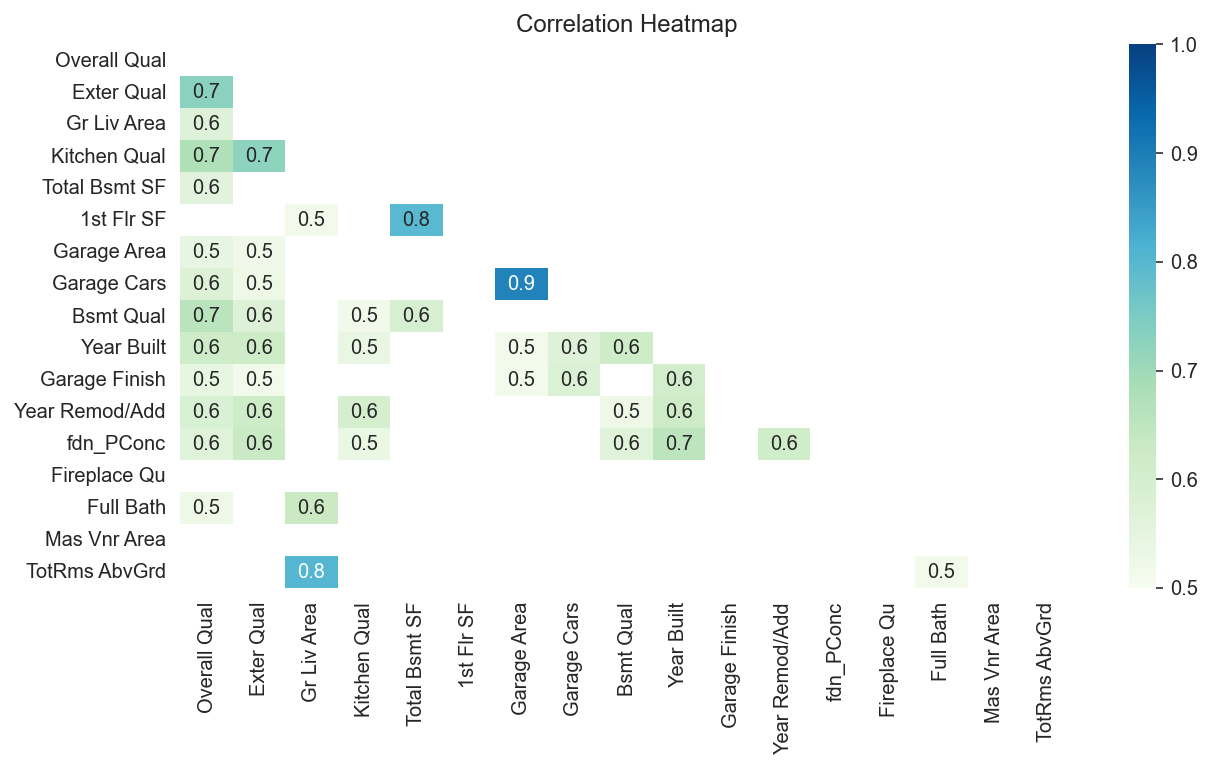

In [216]:
# Create correlation matrix from train data excluding `SalePrice`
corr_df = train_set[corr_05].corr()

# Show only correlations greater than 0.5
corr = corr_df[abs(corr_df) >= 0.5]

# apply masking
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

# Plot correlation heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(corr,
            annot=True,
            fmt='.1f',
            cmap='GnBu',
            mask=mask,
            vmin=0.5,
            vmax=1)
title = plt.title('Correlation Heatmap')

There is multicollinearity between many features. The features with highest correlations are:
* `Gr Liv Area` and `TotRms AbvGrd`
* `1st Flr SF` and `Total Bsmt SF`
* `Garage Cars` and `Garage Area`

In [217]:
corr_train = train_set.corr().SalePrice.sort_values(ascending=False)
corr_train.head(18)

SalePrice         1.000000
Overall Qual      0.803727
Exter Qual        0.727130
Gr Liv Area       0.707312
Kitchen Qual      0.683617
Total Bsmt SF     0.672971
1st Flr SF        0.650016
Garage Area       0.645257
Garage Cars       0.643094
Bsmt Qual         0.620127
Year Built        0.596637
Garage Finish     0.564023
Year Remod/Add    0.556386
Full Bath         0.539955
Fireplace Qu      0.536226
fdn_PConc         0.535120
Mas Vnr Area      0.523031
TotRms AbvGrd     0.484751
Name: SalePrice, dtype: float64

The features with the highest correlations with `SalePrice` also tend to share multicollinearity with each other. Even though multicollinearity would have a negative impact on our prediction models, attempting feature selection using VIF scores resulted in removal of many features that were strong predictors for `SalePrice` and also an eventual poor performing model. Hence, I decided to stick with my current feature selection `corr_05`.

## Kaggle Submission preparation
---

**Contents:**
* [Original test set](#test_df)
* [Dummified test set](#test_dum)
* [Features isolated and imputed test set](#imp_test)
* [Make predictions](#Make-predictions-using-Lasso-Model-from-GridSearchCV)

### test_df

_Import [test.csv](./datasets/test.csv)_

In [218]:
# use test.csv to generate predictions for submission
test_df = pd.read_csv('./datasets/test.csv')

In [219]:
test_df.head(3)

,Id,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type
0,2658,902301120,190,RM,69.0,9142,Pave,Grvl,Reg,Lvl,...,0,0,0,NaN,NaN,NaN,0,4,2006,WD
1,2718,905108090,90,RL,NaN,9662,Pave,NaN,IR1,Lvl,...,0,0,0,NaN,NaN,NaN,0,8,2006,WD
2,2414,528218130,60,RL,58.0,17104,Pave,NaN,IR1,Lvl,...,0,0,0,NaN,NaN,NaN,0,9,2006,New


_Dummify test_df and resolve any null values before getting prediction values because of model restrictions_

In [220]:
'''
Final features to isolate in test set so that model can accept test data to make predictions
'''
print(X_train_17.columns.tolist())
len(X_train_17.columns.tolist())

['Overall Qual', 'Exter Qual', 'Gr Liv Area', 'Kitchen Qual', 'Total Bsmt SF', '1st Flr SF', 'Garage Area', 'Garage Cars', 'Bsmt Qual', 'Year Built', 'Garage Finish', 'Year Remod/Add', 'fdn_PConc', 'Fireplace Qu', 'Full Bath', 'Mas Vnr Area', 'TotRms AbvGrd']


17

Need to group and label the categorical values the same way I did for the training data. Features to focus on are `Overall Qual`, `Exter Qual`, `Kitchen Qual`, `Bsmt Qual`,`Garage Finish`,  `Foundation`,`Fireplace Qu`.

In [221]:
# label encode these categorical features to ordinal numerical values
int_rank1(test_df, col='Exter Qual')
int_rank1(test_df, col='Kitchen Qual')
int_rank2(test_df,col='Bsmt Qual')
int_rank2(test_df,col='Fireplace Qu')

In [222]:
# label encode these categorical features to ordinal numerical values
test_df['Garage Finish'].replace({'Fin':3, 'RFn':2, 'Unf':1, np.nan:0}, inplace=True)

In [223]:
# reduce categorical values by grouping
test_df['Foundation'].replace({'BrkTil':'other', 'Slab':'other', 'Stone':'other', 
                                'Wood':'other'
                              }, inplace=True)
# check changes
test_df['Foundation'].value_counts()

PConc     383
CBlock    381
other     114
Name: Foundation, dtype: int64

### test_dum

For consistency with the training set, I dummify the remaining categorical features in the test set as well.

In [224]:
prefix_dict = {'Pool QC': 'pool_qc', 'Misc Feature': 'misc_f', 'Alley': 'alley', 'Fence': 'fence',
              'Garage Qual': 'grge_q','Garage Cond': 'grge_c', 'Garage Type': 'grge_t', 
               'Bsmt Exposure': 'bsmt_e', 'BsmtFin Type 2': 'bsmtf_t2', 
               'BsmtFin Type 1': 'bsmtf_t1', 'Bsmt Cond': 'bsmt_c','Mas Vnr Type': 'mvt',
              'MS Zoning': 'msz', 'Street': 'stt', 'Lot Shape': 'lot_s', 'Land Contour': 'ld_c',
              'Utilities': 'Utls', 'Lot Config': 'lt_c', 'Land Slope': 'ld_s', 
               'Neighborhood': 'nbrhd', 'Condition 1': 'cdn_1', 'Condition 2': 'cdn_2',
              'Bldg Type': 'bdg_t', 'House Style': 'hse_s', 'Roof Style': 'rf_s', 
               'Roof Matl': 'rf_m', 'Exterior 1st': 'ex_1', 'Exterior 2nd': 'ex_2', 
                'Exter Cond': 'ex_c', 'Foundation': 'fdn', 'Heating': 'htg',
               'Heating QC': 'htg_qc', 'Central Air': 'cair', 'Electrical': 'elec', 
                'Functional': 'func', 'Paved Drive': 'pvdr', 'Sale Type': 'sle_t'
              }

columns_list = ['Pool QC','Misc Feature','Alley','Fence','Garage Qual','Garage Cond',
                'Garage Type','Bsmt Exposure','BsmtFin Type 2','BsmtFin Type 1','Bsmt Cond',
                'Mas Vnr Type','MS Zoning','Street','Lot Shape','Land Contour','Utilities',
                'Lot Config','Land Slope','Neighborhood','Condition 1','Condition 2',
                'Bldg Type', 'House Style','Roof Style','Roof Matl','Exterior 1st',
                'Exterior 2nd','Exter Cond','Foundation','Heating','Heating QC','Central Air',
                'Electrical','Functional','Paved Drive','Sale Type'
               ]

test_dum = pd.get_dummies(data=test_df, prefix=prefix_dict, dummy_na=True, columns=columns_list)
test_dum.head(3)

,Id,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,sle_t_CWD,sle_t_Con,sle_t_ConLD,sle_t_ConLI,sle_t_ConLw,sle_t_New,sle_t_Oth,sle_t_VWD,sle_t_WD,sle_t_nan
0,2658,902301120,190,69.0,9142,6,8,1910,1950,0.0,...,0,0,0,0,0,0,0,0,1,0
1,2718,905108090,90,NaN,9662,5,4,1977,1977,0.0,...,0,0,0,0,0,0,0,0,1,0
2,2414,528218130,60,58.0,17104,7,5,2006,2006,0.0,...,0,0,0,0,0,1,0,0,0,0


In [225]:
test_select = test_dum[X_train_17.columns.tolist()]

In [226]:
# check for null values
test_select.isnull().sum().sort_values(ascending=False)[:3]

Mas Vnr Area    1
Overall Qual    0
Year Built      0
dtype: int64

### imp_test

I am not allowed to drop any rows. So I will have to do KNN imputation for this missing value in `Mas Vnr Area` in `test_select`.

In [227]:
# instantiate KNN imputer
imp_17 = KNNImputer()

In [228]:
# use KNNImputer fitted on X_train_17, transform test set (matched features)
imp_17 = imp.fit(X_train_17)
imp_test = imp_17.transform(test_select)

In [229]:
imp_test = pd.DataFrame(imp_test, columns=test_select.columns)

In [230]:
# relook at what null values that are left 
imp_test.isnull().sum().sort_values(ascending=False)[:3]

Overall Qual    0
Year Built      0
Mas Vnr Area    0
dtype: int64

In [231]:
imp_test.shape

(878, 17)

### Make predictions using Lasso Model from GridSearchCV

In [232]:
# generate predictions using the GridsearchCV Lasso model fitted on the training set
test_pred = pipe3_gs.predict(imp_test)
len(test_pred)

878

In [233]:
# isolate `Id` column from test_df
test_final = test_df[['Id']]
test_final.head(3)

,Id
0,2658
1,2718
2,2414


In [234]:
'''
predictions are in a list format. 
Need to make new column to input prediction values 
'''
test_final['SalePrice'] = test_pred
test_final.head(3)

C:\Users\Maybelle\AppData\Local\Temp\ipykernel_7040\2170739544.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_final['SalePrice'] = test_pred


,Id,SalePrice
0,2658,136436.032460
1,2718,216096.836207
2,2414,195675.585851


In [235]:
# Export file for submission
test_final.to_csv('./kaggle_submission.csv', index=False)

>**User:** yxmauw <br>
**Kaggle score achieved:** 34851.38555 <br>
**Private score:** 27421.05786

Linear models are not great for `SalePrice` predictions using this current data set. I also did not choose to use log for feature engineering as the shape of datapoints spread each feature on scatterplots did not seem suitable for logging. To optimise the model performance: 
* I would like to take a more granular approach in identifying and excluding outliers. 
* I would also prefer to collect a more complete set of data, or more data.
* I would get domain expert opinion on what features are well known to correspond to housing `SalePrice`. 
* I would like to use other types of model, other than linear models for this data set. 

## Business case for project 2
---

To develop a web application where homeowners who wish to sell their property can use to find out what `SalePrice` to sell their property for. The webpage will have specific fields for visitors to fill and submit details about their property. Using our proprietary machine learning algorithm, the application will generate an estimate visitors can use as reference to quote their property `SalePrice`. 

__Steps taken:__
1. [Find common features](#Find-common-features-used-in-all-group-members'-models:)
1. [Find best model](#Group-work-model:)
1. [Polynomial feature engineering](#Polynomial-feature-engineering-to-see-if-it-makes-pipe8_gs-model-more-accurate)
1. [Set up web application](#Set-up-data-file-for-model-training-in-Streamlit-web-application:)

##### Find common features used in all group members' models:

In [236]:
print(corr_05)

['Overall Qual', 'Exter Qual', 'Gr Liv Area', 'Kitchen Qual', 'Total Bsmt SF', '1st Flr SF', 'Garage Area', 'Garage Cars', 'Bsmt Qual', 'Year Built', 'Garage Finish', 'Year Remod/Add', 'fdn_PConc', 'Fireplace Qu', 'Full Bath', 'Mas Vnr Area', 'TotRms AbvGrd']


In [237]:
tiek_leong_features = ['MS Zoning', 'Wood Deck SF', 'Garage Finish', 'Exterior 1st',
       'Bsmt Full Bath', 'TotRms AbvGrd', 'Lot Frontage', 'Fireplace Qu',
       'Neighborhood', 'Lot Area', 'Garage Area', 'Bsmt Exposure',
       'Overall Cond', 'Kitchen Qual', 'Exter Qual', 'Mas Vnr Area',
       'Total Bsmt SF', 'Year Built', 'BsmtFin SF 1', '1st Flr SF',
       '2nd Flr SF', 'Gr Liv Area', 'Overall Qual']

In [238]:
anand_features = ['Overall Qual','Gr Liv Area','Total Bsmt SF',  
                   'Garage Area','Year Built','Year Remod/Add','fdn_PConc', 
                   'Mas Vnr Area','Fireplaces','bsmtfin_type_1_gq']

To refine the features for our machine learning algorithm, we find the features that are present in all 3 group members final model feature selection.

In [239]:
def common_features(lst_1, lst_2, lst_3):
    lst = []
    for x in lst_1:
        for y in lst_2:
            for z in lst_3:
                if x==y==z:
                    lst.append(x)
    return lst

In [240]:
com_list = common_features(corr_05, tiek_leong_features, anand_features)
print(com_list)

['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Garage Area', 'Year Built', 'Mas Vnr Area']


There are 6 features that are common across all 3 group members final model feature selection. 
However, 1 out of the 6 features is quite subjective for visitors to fill in on the website. Therefore, I decided that for any new data from the website, `Overall Qual` will be imputed based on KNNImputer fitted on training data and fed to the algorithm to generate a prediction.

##### Group work model:

In [241]:
grp_X_train = imp_X_train[com_list]
grp_X_test = imp_X_test[com_list]

In [242]:
# Instantiate a StandardScaler + LR pipeline.
pipe5 = Pipeline([
    ('ss', StandardScaler()),
    ('lr', LinearRegression())
])

# Instantiate a StandardScaler + Ridge pipeline.
pipe6 = Pipeline([
    ('ss', StandardScaler()),
    ('ridge', Ridge())
])

# Instantiate a StandardScaler + LASSO pipeline.
pipe7 = Pipeline([
    ('ss', StandardScaler()),
    ('lasso', Lasso())
])

# Instantiate a StandardScaler + ElasticNet pipeline.
pipe8 = Pipeline([
    ('ss', StandardScaler()),
    ('enet', ElasticNet())
])

In [243]:
# Create dictionary of hyperparameters.
enet_ratio = [.5,.8,.9,.95]
n_neighbors = [3,5,10]
alpha_l = [1.,10.,100.,500.,1000.]

pipe5_params = {'lr__fit_intercept': [True, False],
                'lr__positive': [True, False]
               }

pipe6_params = {'ridge__alpha': alpha_l
               }

pipe7_params = {'lasso__alpha': alpha_l,
                'lasso__max_iter': [10000, 50000]
               }

pipe8_params = {'enet__alpha': alpha_l,
                'enet__l1_ratio': enet_ratio
               }

In [244]:
cv_ct = 5
score = 'neg_root_mean_squared_error'

pipe5_gs = GridSearchCV(pipe5,
                       pipe5_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

pipe6_gs = GridSearchCV(pipe6,
                       pipe6_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

pipe7_gs = GridSearchCV(pipe7,
                       pipe7_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

pipe8_gs = GridSearchCV(pipe8,
                       pipe8_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

In [245]:
# combine the grids to loop through
grids = [pipe5_gs, pipe6_gs, pipe7_gs, pipe8_gs]

for pipe in grids:
    pipe.fit(grp_X_train,y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


_**Evaluate models**_

In [246]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [247]:
y_bar = np.repeat(np.mean(y_train),(len(y_train)))
y_bar_rmse = mean_squared_error(y_train, y_bar, squared=False)

grid_dict = {0: 'Linear regression', 1: 'Ridge regression',
            2: 'Lasso regression', 3: 'ElasticNet regression'}

for i, model in enumerate(grids):
    print(f'y_bar rmse: {y_bar_rmse}')
    print(f'{grid_dict[i]} train mae: {mean_absolute_error(y_train, model.predict(grp_X_train))}')
    print(f'{grid_dict[i]} test mae: {mean_absolute_error(y_test, model.predict(grp_X_test))}')
    print(f'{grid_dict[i]} train rmse: {model.score(grp_X_train, y_train)}')
    print(f'{grid_dict[i]} test rmse: {model.score(grp_X_test, y_test)}')
    print(f'{grid_dict[i]} %_diff rmse: {((model.score(grp_X_train, y_train)-model.score(grp_X_test, y_test))*100)/model.score(grp_X_train, y_train)} %')
    print(f'{grid_dict[i]} Best Params: {model.best_params_}')
    print()

y_bar rmse: 77440.56492336537
Linear regression train mae: 23290.761142714884
Linear regression test mae: 22961.634764060276
Linear regression train rmse: -32379.60416873587
Linear regression test rmse: -31894.900400215545
Linear regression %_diff rmse: 1.4969416117456147 %
Linear regression Best Params: {'lr__fit_intercept': True, 'lr__positive': False}

y_bar rmse: 77440.56492336537
Ridge regression train mae: 23265.199040220177
Ridge regression test mae: 22931.179176260044
Ridge regression train rmse: -32380.284122432033
Ridge regression test rmse: -31890.02987312427
Ridge regression %_diff rmse: 1.514051721887551 %
Ridge regression Best Params: {'ridge__alpha': 10.0}

y_bar rmse: 77440.56492336537
Lasso regression train mae: 23290.598394459776
Lasso regression test mae: 22961.476676809296
Lasso regression train rmse: -32379.604207793207
Lasso regression test rmse: -31894.986561214908
Lasso regression %_diff rmse: 1.4966756340451504 %
Lasso regression Best Params: {'lasso__alpha': 1

For the ease of interpretation by users of the website, we will be using mean absolute error(MAE) as the range of error to include in our `SalePrice` predictions when displaying the `SalePrice` quote to users. 

Therefore, the best linear model based on lowest MAE score is `ElasticNet`, which I will attempt to fine tune, before deploying to the website.

In [248]:
enet_ratio = np.linspace(.5,1,50)
alpha_l = np.linspace(.01,1,50)

pipe_enet = Pipeline([
    ('imp', KNNImputer()),
    ('ss', StandardScaler()),
    ('enet', ElasticNet())
])

pipe_enet_params = {'enet__alpha': alpha_l,
                'enet__l1_ratio': enet_ratio
               }

In [249]:
cv_ct = 5
score = 'neg_root_mean_squared_error'

pipe_enet_gs = GridSearchCV(pipe_enet,
                       pipe_enet_params,
                       cv=cv_ct,
                       scoring=score,
                       verbose=1
                       )

In [250]:
pipe_enet_gs.fit(grp_X_train,y_train)

Fitting 5 folds for each of 2500 candidates, totalling 12500 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imp', KNNImputer()),
                                       ('ss', StandardScaler()),
                                       ('enet', ElasticNet())]),
             param_grid={'enet__alpha': array([0.01      , 0.03020408, 0.05040816, 0.07061224, 0.09081633,
       0.11102041, 0.13122449, 0.15142857, 0.17163265, 0.19183673,
       0.21204082, 0.2322449 , 0.25244898, 0.27265306, 0.29285714,
       0.31306122, 0.33326531, 0.35346939, 0.37367347, 0....
       0.70408163, 0.71428571, 0.7244898 , 0.73469388, 0.74489796,
       0.75510204, 0.76530612, 0.7755102 , 0.78571429, 0.79591837,
       0.80612245, 0.81632653, 0.82653061, 0.83673469, 0.84693878,
       0.85714286, 0.86734694, 0.87755102, 0.8877551 , 0.89795918,
       0.90816327, 0.91836735, 0.92857143, 0.93877551, 0.94897959,
       0.95918367, 0.96938776, 0.97959184, 0.98979592, 1.        ])},
             scoring='neg_root_mean_squared_error', verbose=1)

In [251]:
y_bar = np.repeat(np.mean(y_train),(len(y_train)))
y_bar_rmse = mean_squared_error(y_train, y_bar, squared=False)

print(f'y_bar rmse: {y_bar_rmse}')
print(f'Elastic Net train mae: {mean_absolute_error(y_train, pipe_enet_gs.predict(grp_X_train))}')
print(f'Elastic Net test mae: {mean_absolute_error(y_test, pipe_enet_gs.predict(grp_X_test))}')
print(f'Elastic Net train rmse: {pipe_enet_gs.score(grp_X_train, y_train)}')
print(f'Elastic Net test rmse: {pipe_enet_gs.score(grp_X_test, y_test)}')
print(f'Elastic Net %_diff rmse: {((pipe_enet_gs.score(grp_X_train, y_train)-pipe_enet_gs.score(grp_X_test, y_test))*100)/pipe_enet_gs.score(grp_X_train, y_train)} %')
print(f'Elastic Net Best Params: {pipe_enet_gs.best_params_}')

y_bar rmse: 77440.56492336537
Elastic Net train mae: 23249.08968920516
Elastic Net test mae: 22911.71267514649
Elastic Net train rmse: -32381.435620949662
Elastic Net test rmse: -31887.67032960571
Elastic Net %_diff rmse: 1.5248406436449145 %
Elastic Net Best Params: {'enet__alpha': 0.030204081632653063, 'enet__l1_ratio': 0.6122448979591837}


Unfortunately, the fine tuning using just ElasticNet within GridSearchCV did not result in a better MAE score compared to `pipe8_gs`. Therefore I will use `pipe8_gs` as the model to deploy in the website.

##### Polynomial feature engineering to see if it makes `pipe8_gs` model more accurate

In [285]:
from sklearn.preprocessing import PolynomialFeatures

In [265]:
# rank correlation
st_data.corr().SalePrice.sort_values(ascending=False)

SalePrice        1.000000
Overall Qual     0.805464
Gr Liv Area      0.715639
Total Bsmt SF    0.671040
Garage Area      0.651454
Year Built       0.594510
Mas Vnr Area     0.529145
Name: SalePrice, dtype: float64

In [286]:
# Instantiate PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias=False)

In [326]:
# fit and transform data
X_poly_train = poly.fit_transform(grp_X_train[['Gr Liv Area']])
X_poly_test = poly.transform(grp_X_test[['Gr Liv Area']])

I decided to choose `Gr Liv Area` for polynomial feature engineering because its correlation factor with `SalePrice` is 0.7-0.9 (implies strong relationship). I did not choose `Overall Qual` for polynomial feature engineering because as mentioned [earlier](#Find-common-features-used-in-all-group-members'-models:), this feature would become imputed for future new data entered in the web application, and I do not wish to increase the influence of imputed data fed into the model. <br><br> I also attempted to do polynomial feature engineering for features with correlation strength between 0.6 and 0.7, however it caused the model to become overfitted on the training data, and lower generalisation. 

In [327]:
# convert to pd.dataframe
X_poly_train = pd.DataFrame(X_poly_train, columns=poly.get_feature_names_out(['Gr Liv Area']))
X_poly_test = pd.DataFrame(X_poly_test, columns=poly.get_feature_names_out(['Gr Liv Area']))

In [329]:
# join with original dataframe
X_poly_train = pd.concat([X_poly_train, grp_X_train], axis=1)
X_poly_train.head(3)

,Gr Liv Area,Gr Liv Area^2,Gr Liv Area^3,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Year Built,Mas Vnr Area,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Year Built,Mas Vnr Area
0,1320.0,1742400.0,2.299968e+09,5.0,1320.0,1164.0,564.0,1966.0,97.0,5.0,1320.0,1164.0,564.0,1966.0,97.0
1,1950.0,3802500.0,7.414875e+09,9.0,1950.0,1950.0,706.0,2007.0,480.0,9.0,1950.0,1950.0,706.0,2007.0,480.0
2,2599.0,6754801.0,1.755573e+10,9.0,2599.0,1393.0,779.0,1999.0,165.0,9.0,2599.0,1393.0,779.0,1999.0,165.0


In [330]:
# join with original dataframe
X_poly_test = pd.concat([X_poly_test, grp_X_test], axis=1)
X_poly_test.head(3)

,Gr Liv Area,Gr Liv Area^2,Gr Liv Area^3,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Year Built,Mas Vnr Area
0,2956.0,8737936.0,2.582934e+10,8.0,2956.0,1706.0,916.0,2004.0,502.0
1,928.0,861184.0,7.991788e+08,5.0,928.0,928.0,288.0,1957.0,0.0
2,1264.0,1597696.0,2.019488e+09,5.0,1264.0,1268.0,461.0,1960.0,324.0


In [331]:
# drop duplicate columns
X_drop_train = X_poly_train.T.drop_duplicates().T
X_drop_train.head(3)

,Gr Liv Area,Gr Liv Area^2,Gr Liv Area^3,Overall Qual,Total Bsmt SF,Garage Area,Year Built,Mas Vnr Area
0,1320.0,1742400.0,2.299968e+09,5.0,1164.0,564.0,1966.0,97.0
1,1950.0,3802500.0,7.414875e+09,9.0,1950.0,706.0,2007.0,480.0
2,2599.0,6754801.0,1.755573e+10,9.0,1393.0,779.0,1999.0,165.0


In [332]:
# drop duplicate columns
X_drop_test = X_poly_test.T.drop_duplicates().T
X_drop_test.head(3)

,Gr Liv Area,Gr Liv Area^2,Gr Liv Area^3,Overall Qual,Total Bsmt SF,Garage Area,Year Built,Mas Vnr Area
0,2956.0,8737936.0,2.582934e+10,8.0,1706.0,916.0,2004.0,502.0
1,928.0,861184.0,7.991788e+08,5.0,928.0,288.0,1957.0,0.0
2,1264.0,1597696.0,2.019488e+09,5.0,1268.0,461.0,1960.0,324.0


In [333]:
# fit model on data with polynomial feature
pipe8_gs.fit(X_drop_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('ss', StandardScaler()),
                                       ('enet', ElasticNet())]),
             param_grid={'enet__alpha': [1.0, 10.0, 100.0, 500.0, 1000.0],
                         'enet__l1_ratio': [0.5, 0.8, 0.9, 0.95]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [334]:
y_bar = np.repeat(np.mean(y_train),(len(y_train)))
y_bar_rmse = mean_squared_error(y_train, y_bar, squared=False)

print(f'y_bar rmse: {y_bar_rmse}')
print(f'Elastic Net train mae: {mean_absolute_error(y_train, pipe8_gs.predict(X_drop_train))}')
print(f'Elastic Net test mae: {mean_absolute_error(y_test, pipe8_gs.predict(X_drop_test))}')
print(f'Elastic Net train rmse: {pipe8_gs.score(X_drop_train, y_train)}')
print(f'Elastic Net test rmse: {pipe8_gs.score(X_drop_test, y_test)}')
print(f'Elastic Net %_diff rmse: {((pipe8_gs.score(X_drop_train, y_train)-pipe8_gs.score(X_drop_test, y_test))*100)/pipe8_gs.score(X_drop_train, y_train)} %')
print(f'Elastic Net Best Params: {pipe8_gs.best_params_}')

y_bar rmse: 77440.56492336537
Elastic Net train mae: 22321.359763827888
Elastic Net test mae: 22033.520762452332
Elastic Net train rmse: -31650.812289508798
Elastic Net test rmse: -30823.747095848474
Elastic Net %_diff rmse: 2.613093105147476 %
Elastic Net Best Params: {'enet__alpha': 1.0, 'enet__l1_ratio': 0.95}


Reference  metrics from `pipe8_gs` model performance on grp_X_train, y_train data:

There is slight overall improvement, without significant reduction in generalisation. Therefore I will use the data with polynomial `Gr Liv Area` features for deployment on my web application.

##### Set up data file for model training in Streamlit web application: 

In [339]:
# join grp_X_train with y_train to provide data to model in streamlit 
st_train = pd.concat([X_drop_train, y_train], axis=1)
st_train.head(3)

,Gr Liv Area,Gr Liv Area^2,Gr Liv Area^3,Overall Qual,Total Bsmt SF,Garage Area,Year Built,Mas Vnr Area,SalePrice
0,1320.0,1742400.0,2.299968e+09,5.0,1164.0,564.0,1966.0,97.0,164500
1,1950.0,3802500.0,7.414875e+09,9.0,1950.0,706.0,2007.0,480.0,383000
2,2599.0,6754801.0,1.755573e+10,9.0,1393.0,779.0,1999.0,165.0,333168


In [340]:
y_test.reset_index(drop=True, inplace=True) #y_train indices are not the same as grp_X_train

In [341]:
# join grp_X_test with y_test to st_data
st_test = pd.concat([X_drop_test, y_test], axis=1)

In [342]:
st_data = pd.concat([st_train, st_test], axis=0)

In [343]:
st_data.shape

(2012, 9)

In [344]:
st_data.to_csv('./app/streamlit_data.csv', index=False)

##### Set up data file for imputation fitting in Streamlit website: 

In [345]:
st_imp = pd.concat([X_drop_train, X_drop_test], axis=0)
st_imp.shape

(2012, 8)

In [346]:
st_imp.to_csv('./app/streamlit_imp_data.csv', index=False)

In [347]:
# predicted SalePrice
pred_arr = pipe8_gs.predict(X_drop_train).round(2)

In [348]:
for i in range(5):
    print(f'Predicted Saleprice: {pred_arr[i]}')
    print(f'True Saleprice: {y_train[i]}')
    print()

Predicted Saleprice: 157496.24
True Saleprice: 164500

Predicted Saleprice: 323336.97
True Saleprice: 383000

Predicted Saleprice: 339082.42
True Saleprice: 333168

Predicted Saleprice: 136292.43
True Saleprice: 120000

Predicted Saleprice: 298416.51
True Saleprice: 281213

